In [3]:
import pandas as pd 

hc_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/hc_final.csv")
stroke_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/stroke_final.csv")

print(hc_df)
print(stroke_df)

           AU01      AU02      AU04      AU05      AU06  AU07      AU09  \
0      0.662852  0.624610  0.314624  0.281805  0.552826   1.0  0.578481   
1      0.588522  0.729912  0.148455  0.311635  0.551176   1.0  0.493552   
2      0.618330  0.614358  0.219440  0.308120  0.576201   1.0  0.543342   
3      0.617469  0.512366  0.267159  0.313158  0.601808   1.0  0.555102   
4      0.615463  0.565650  0.231532  0.319425  0.566009   1.0  0.462272   
...         ...       ...       ...       ...       ...   ...       ...   
62263  0.189289  0.159416  0.352825  0.287602  0.647014   1.0  0.280831   
62264  0.155436  0.189937  0.169199  0.277864  0.639085   1.0  0.318632   
62265  0.151962  0.298684  0.139264  0.275850  0.729294   1.0  0.334046   
62266  0.166659  0.206982  0.233789  0.296108  0.711444   0.0  0.258027   
62267  0.258787  0.212485  0.247769  0.364380  0.631447   1.0  0.222497   

           AU10  AU11      AU12  ...      AU23      AU24      AU25      AU26  \
0      0.002910   1

In [7]:
au_cols = [c for c in hc_df.columns if c.startswith("AU")]

print("HC min:", hc_df[au_cols].min().min())
print("HC max:", hc_df[au_cols].max().max())

print("Stroke min:", stroke_df[au_cols].min().min())
print("Stroke max:", stroke_df[au_cols].max().max())

HC min: 0.0
HC max: 1.0
Stroke min: 0.0
Stroke max: 1.0


In [8]:
# Convert numeric labels to string
hc_df["diagnosed"] = "HC"
stroke_df["diagnosed"] = "Stroke"

# Drop old label column (if still exists)
hc_df = hc_df.drop(columns=["label"], errors='ignore')
stroke_df = stroke_df.drop(columns=["label"], errors='ignore')

# Concatenate into one dataframe
df = pd.concat([hc_df, stroke_df], ignore_index=True)

# Check the structure
print(df.columns)
print(df["diagnosed"].value_counts())

Index(['AU01', 'AU02', 'AU04', 'AU05', 'AU06', 'AU07', 'AU09', 'AU10', 'AU11',
       'AU12', 'AU14', 'AU15', 'AU17', 'AU20', 'AU23', 'AU24', 'AU25', 'AU26',
       'AU28', 'AU43', 'frame', 'participant_id', 'task', 'diagnosed'],
      dtype='object')
diagnosed
Stroke    81636
HC        62268
Name: count, dtype: int64


Video: N001_02_BBP_NORMAL


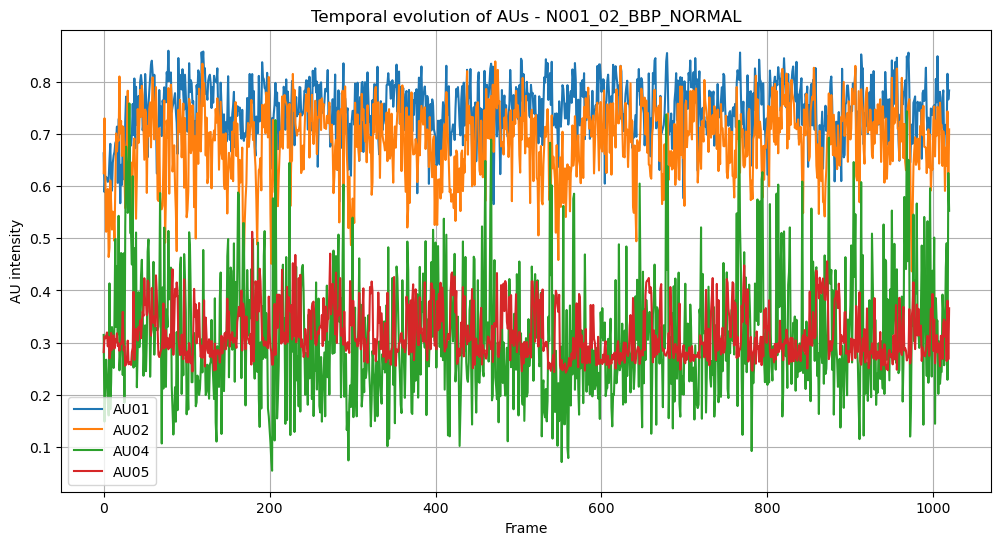

In [10]:
import matplotlib.pyplot as plt

# create video column if not already done
df["video"] = df["participant_id"].astype(str) + "_" + df["task"].astype(str)

# pick one video
v = df["video"].unique()[0]

print("Video:", v)

# get data for that video (IMPORTANT: sort by frame!)
sub = df[df["video"] == v].sort_values("frame")

frames = sub["frame"].values

# select some AUs to visualize
au_cols = [c for c in df.columns if c.startswith("AU")]
aus_to_plot = au_cols[:4]  # first 4 AUs (or choose manually)

plt.figure(figsize=(12,6))

for au in aus_to_plot:
    plt.plot(frames, sub[au].values, label=au)

plt.xlabel("Frame")
plt.ylabel("AU intensity")
plt.title(f"Temporal evolution of AUs - {v}")
plt.legend()
plt.grid(True)

plt.show()

In [41]:
import pandas as pd 
df = df.rename(columns={"participant_id": "patient_id"})
df=df.dropna()


tasks = ['BBP_NORMAL', 'DDK_PATAKA', 'DDK_PA', 'NSM_KISS', 'NSM_OPEN', 'NSM_SPREAD', 'NSM_BLOW']
statistics = ['var', 'mean', 'min', 'max', 'std']
all_action_unit = ['AU01', 'AU02', 'AU04', 'AU05', 'AU06', 'AU07', 'AU09', 'AU10', 'AU11', 'AU12', 'AU14', 'AU15', 'AU17', 'AU20', 'AU23', 'AU24', 'AU25', 'AU26', 'AU28', 'AU43'] 

In [42]:
print(df['task'].unique())

['BBP_NORMAL' 'DDK_PA' 'DDK_PATAKA' 'NSM_BLOW' 'NSM_KISS' 'NSM_OPEN'
 'NSM_SPREAD']


In [43]:
from sklearn.base import BaseEstimator, TransformerMixin

class GroupTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, task, statistics, disease):
        self.task = task
        self.method = statistics
        self.disease = disease 

    def fit(self, X, y=None):
        return self
    def transform(self, df, y = None):
        X = df[ ( df['task']== self.task)].copy()
        X = X.drop(columns=["frame"], errors="ignore")
        if self.disease is not None:
            X = X[ (X['diagnosed']== self.disease) | (X['diagnosed']=='HC')]

        if self.method=='min':
            X=X.groupby(['patient_id', 'task', 'diagnosed']).min().reset_index()
        elif self.method=='mean':
            X=X.groupby(['patient_id', 'task', 'diagnosed']).mean().reset_index()
        elif self.method=='max':
            X=X.groupby(['patient_id', 'task', 'diagnosed']).max().reset_index()
        elif self.method=='var':
            X=X.groupby(['patient_id', 'task', 'diagnosed']).var().reset_index()
        elif self.method=='std':
            X=X.groupby(['patient_id', 'task', 'diagnosed']).std().reset_index()

        y= X['diagnosed'].apply(lambda x : 0 if x=='HC' else 1).astype(int).values.ravel()

        X = X.set_index("patient_id")
        x = X.drop(columns=['diagnosed', 'task'])

        return (x,y)
    
    

Grid Search

In [44]:
from sklearn.model_selection import GridSearchCV, LeaveOneOut, cross_val_predict
from imblearn.pipeline import Pipeline 
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.preprocessing import StandardScaler 

param_grid = [
    {
        'clf': [LogisticRegression()],
        'clf__solver': ['liblinear'],
        'clf__penalty': ['l1', 'l2'],
        'clf__C': list(np.arange(0.0001,100.3,.3)),
        'clf__random_state':[42],
    }
]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC 
from sklearn import svm
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
 
def make_bold(number):
    if round(number,2)>=0.7:
        return f"\\textbf{{{number:.2f}}}"
    else:
        return f"{number:.2f}"
    
results_list = []

for params in param_grid:
    perform=""
    print(f"----------------{params['clf']}-----------------")
    for task in tasks:
        perform= perform + f"\multirow{{ 5}}{{*}}{{\\textbf{{{task}}} }}" + "\n"
        for measure in statistics:

            feat = GroupTransformer(task, measure, 'Stroke')
            x,y = feat.transform(df)

            # Split into train/test - adicionado
            X_train, X_test, y_train, y_test = train_test_split(
                x, y, test_size=0.2, stratify=y, random_state=50
            )


            #pipeline
            steps = [
                ('norm', StandardScaler()),
                ('clf', LogisticRegression()) ]
            pipe = Pipeline(steps=steps)

            search = GridSearchCV(pipe, params, cv = LeaveOneOut(), n_jobs = -1,
            scoring='accuracy', refit=True ).fit(X_train,y_train)

            y_hat_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
            #y_hat_proba= cross_val_predict(search.best_estimator_, X, y, cv=LeaveOneOut(), method="predict_proba")
            #y_hat_proba= y_hat_proba[:, 1]
            y_hat = (y_hat_proba>=0.5).astype(int)

            accuracy = accuracy_score(y_test,y_hat)
            sensitivity = recall_score(y_test,y_hat)
            specificity = recall_score(y_test,y_hat, pos_label=0)
            f1score = f1_score(y_test, y_hat)
            auc = roc_auc_score(y_test, y_hat_proba)

            results_list.append({
                "Task": task,
                "Statistic": measure,
                "Accuracy": round(accuracy, 2),
                "Sensitivity": round(sensitivity, 2),
                "Specificity": round(specificity, 2),
                "F1 Score": round(f1score, 2),
                "AUC": round(auc, 2)
            })

            perform = perform + f"{search.best_estimator_} & {measure} & {make_bold(accuracy)} & {make_bold(sensitivity)} & {make_bold(specificity)} \\\\ \n"

        perform= perform + f"\midrule\n"
    print(perform)
# === Save results to CSV
results_df = pd.DataFrame(results_list)
results_df.to_csv("logreg_results_poststroke_correto.csv", index=False)

----------------[LogisticRegression()]-----------------
\multirow{ 5}{*}{\textbf{BBP_NORMAL} }
Pipeline(steps=[('norm', StandardScaler()),
                ('clf',
                 LogisticRegression(C=0.3001, penalty='l1', random_state=42,
                                    solver='liblinear'))]) & var & 0.40 & 0.67 & 0.00 \\ 
Pipeline(steps=[('norm', StandardScaler()),
                ('clf',
                 LogisticRegression(C=0.0001, penalty='l1', random_state=42,
                                    solver='liblinear'))]) & mean & 0.60 & \textbf{1.00} & 0.00 \\ 
Pipeline(steps=[('norm', StandardScaler()),
                ('clf',
                 LogisticRegression(C=0.0001, penalty='l1', random_state=42,
                                    solver='liblinear'))]) & min & 0.60 & \textbf{1.00} & 0.00 \\ 
Pipeline(steps=[('norm', StandardScaler()),
                ('clf',
                 LogisticRegression(C=3.3001, random_state=42,
                                    solver='liblin

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC 
from sklearn import svm
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
 
def make_bold(number):
    if round(number,2)>=0.7:
        return f"\\textbf{{{number:.2f}}}"
    else:
        return f"{number:.2f}"
    
results_list = []

for params in param_grid:
    perform=""
    print(f"----------------{params['clf']}-----------------")
    for task in tasks:
        perform= perform + f"\multirow{{ 5}}{{*}}{{\\textbf{{{task}}} }}" + "\n"
        for measure in statistics:

            feat = GroupTransformer(task, measure, 'Stroke')
            x,y = feat.transform(df)


            loo_outer = LeaveOneOut()
            y_true, y_pred, y_proba = [], [], []

            for train_idx, test_idx in loo_outer.split(x):
                X_train, X_test = x.iloc[train_idx], x.iloc[test_idx]
                y_train, y_test = y[train_idx], y[test_idx]



                #pipeline
                steps = [
                    ('norm', StandardScaler()),
                    ('clf', LogisticRegression()) ]
                pipe = Pipeline(steps=steps)

                search = GridSearchCV(pipe, params, cv = LeaveOneOut(), n_jobs = -1,
                scoring='accuracy', refit=True ).fit(X_train,y_train)

                y_hat_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
                #y_hat_proba= cross_val_predict(search.best_estimator_, X_test, y_test, cv=LeaveOneOut(), method="predict_proba")
                #y_hat_proba= y_hat_proba[:, 1]
                y_hat = (y_hat_proba>=0.5).astype(int)

                y_true.extend(y_test)
                y_pred.extend(y_hat)
                y_proba.extend(y_hat_proba)


            accuracy = accuracy_score(y_true, y_pred)
            sensitivity = recall_score(y_true, y_pred)
            specificity = recall_score(y_true, y_pred, pos_label=0)
            f1score = f1_score(y_true, y_pred)
            auc = roc_auc_score(y_true, y_proba)

            results_list.append({
                "Task": task,
                "Statistic": measure,
                "Accuracy": round(accuracy, 2),
                "Sensitivity": round(sensitivity, 2),
                "Specificity": round(specificity, 2),
                "F1 Score": round(f1score, 2),
                "AUC": round(auc, 2)
            })

            perform = perform + f"{search.best_estimator_} & {measure} & {make_bold(accuracy)} & {make_bold(sensitivity)} & {make_bold(specificity)} \\\\ \n"

        perform= perform + f"\midrule\n"
    print(perform)
# === Save results to CSV
results_df = pd.DataFrame(results_list)
results_df.to_csv("logreg_results_poststroke_2loops.csv", index=False)

----------------[LogisticRegression()]-----------------


python(28178) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(28179) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(28180) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(28181) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(28182) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(28183) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(28184) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(28185) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/beatrizrebelo/anacon

\multirow{ 5}{*}{\textbf{BBP_NORMAL} }
Pipeline(steps=[('norm', StandardScaler()),
                ('clf',
                 LogisticRegression(C=0.9000999999999999, random_state=42,
                                    solver='liblinear'))]) & var & 0.44 & 0.57 & 0.27 \\ 
Pipeline(steps=[('norm', StandardScaler()),
                ('clf',
                 LogisticRegression(C=0.3001, penalty='l1', random_state=42,
                                    solver='liblinear'))]) & mean & 0.44 & 0.43 & 0.45 \\ 
Pipeline(steps=[('norm', StandardScaler()),
                ('clf',
                 LogisticRegression(C=0.0001, penalty='l1', random_state=42,
                                    solver='liblinear'))]) & min & 0.48 & \textbf{0.71} & 0.18 \\ 
Pipeline(steps=[('norm', StandardScaler()),
                ('clf',
                 LogisticRegression(C=0.6001, random_state=42,
                                    solver='liblinear'))]) & max & 0.36 & 0.43 & 0.27 \\ 
Pipeline(steps=[('norm', St

In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneOut, GridSearchCV, PredefinedSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

SEED = 42
rng = np.random.default_rng(SEED)

def make_bold(number):
    if round(number, 2) >= 0.7:
        return f"\\textbf{{{number:.2f}}}"
    else:
        return f"{number:.2f}"

results_list = []

for params in param_grid:
    perform = ""
    print(f"----------------{params['clf']}-----------------")

    for task in tasks:
        perform = perform + f"\\multirow{{ 5}}{{*}}{{\\textbf{{{task}}} }}" + "\n"

        for measure in statistics:
            feat = GroupTransformer(task, measure, 'Stroke')
            x, y = feat.transform(df)

            loo_outer = LeaveOneOut()
            y_true, y_pred, y_proba = [], [], []

            for train_idx, test_idx in loo_outer.split(x):
                X_train_full, X_test = x.iloc[train_idx], x.iloc[test_idx]
                y_train_full, y_test = y[train_idx], y[test_idx]

                # ---------------------------------------------------------
                # Pick 2 validation samples per class from the TRAINING set
                # ---------------------------------------------------------
                y_train_full_arr = np.array(y_train_full)
                idx0 = np.where(y_train_full_arr == 0)[0]
                idx1 = np.where(y_train_full_arr == 1)[0]

                val0 = rng.choice(idx0, size=2, replace=False)
                val1 = rng.choice(idx1, size=2, replace=False)
                val_idx_local = np.concatenate([val0, val1])

                train_idx_local = np.array([i for i in range(len(X_train_full)) if i not in set(val_idx_local)])

                # Build a single dataset for GridSearchCV using PredefinedSplit
                X_gs = pd.concat([X_train_full.iloc[train_idx_local], X_train_full.iloc[val_idx_local]], axis=0)
                y_gs = np.concatenate([y_train_full_arr[train_idx_local], y_train_full_arr[val_idx_local]])

                # PredefinedSplit: -1 means "train", 0 means "validation"
                test_fold = np.array([-1] * len(train_idx_local) + [0] * len(val_idx_local))
                ps = PredefinedSplit(test_fold=test_fold)

                # ---------------------------------------------------------
                # Pipeline + GridSearch using ONLY that validation split
                # ---------------------------------------------------------
                steps = [
                    ('norm', StandardScaler()),
                    ('clf', LogisticRegression(max_iter=5000))
                ]
                pipe = Pipeline(steps=steps)

                search = GridSearchCV(
                    pipe,
                    params,
                    cv=ps,
                    n_jobs=-1,
                    scoring='accuracy',
                    refit=True
                ).fit(X_gs, y_gs)

                # ---------------------------------------------------------
                # Predict on OUTER test sample
                # ---------------------------------------------------------
                y_hat_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
                y_hat = (y_hat_proba >= 0.5).astype(int)

                y_true.extend(y_test)
                y_pred.extend(y_hat)
                y_proba.extend(y_hat_proba)

            accuracy = accuracy_score(y_true, y_pred)
            sensitivity = recall_score(y_true, y_pred)
            specificity = recall_score(y_true, y_pred, pos_label=0)
            f1score = f1_score(y_true, y_pred)
            auc = roc_auc_score(y_true, y_proba)

            results_list.append({
                "Task": task,
                "Statistic": measure,
                "Accuracy": round(accuracy, 2),
                "Sensitivity": round(sensitivity, 2),
                "Specificity": round(specificity, 2),
                "F1 Score": round(f1score, 2),
                "AUC": round(auc, 2)
            })

            perform = perform + f"{search.best_estimator_} & {measure} & {make_bold(accuracy)} & {make_bold(sensitivity)} & {make_bold(specificity)} \\\\ \n"

        perform = perform + f"\\midrule\n"

    print(perform)

results_df = pd.DataFrame(results_list)
results_df.to_csv("logreg_poststroke_correto_val2perclass.csv", index=False)
print("Saved logreg_results_poststroke_LOO_test_val_2perclass.csv")

----------------[LogisticRegression()]-----------------


/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


\multirow{ 5}{*}{\textbf{BBP_NORMAL} }
Pipeline(steps=[('norm', StandardScaler()),
                ('clf',
                 LogisticRegression(C=0.0001, random_state=42,
                                    solver='liblinear'))]) & var & 0.44 & 0.64 & 0.18 \\ 
Pipeline(steps=[('norm', StandardScaler()),
                ('clf',
                 LogisticRegression(C=0.0001, random_state=42,
                                    solver='liblinear'))]) & mean & 0.52 & \textbf{0.79} & 0.18 \\ 
Pipeline(steps=[('norm', StandardScaler()),
                ('clf',
                 LogisticRegression(C=0.0001, penalty='l1', random_state=42,
                                    solver='liblinear'))]) & min & 0.52 & \textbf{0.86} & 0.09 \\ 
Pipeline(steps=[('norm', StandardScaler()),
                ('clf',
                 LogisticRegression(C=0.0001, penalty='l1', random_state=42,
                                    solver='liblinear'))]) & max & 0.44 & 0.64 & 0.18 \\ 
Pipeline(steps=[('norm', Stand

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneOut, GridSearchCV, PredefinedSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

SEED = 42
rng = np.random.default_rng(SEED)

def make_bold(number):
    if round(number, 2) >= 0.7:
        return f"\\textbf{{{number:.2f}}}"
    else:
        return f"{number:.2f}"

results_list = []

for params in param_grid:
    perform = ""
    print(f"----------------{params['clf']}-----------------")

    for task in tasks:
        perform = perform + f"\\multirow{{ 5}}{{*}}{{\\textbf{{{task}}} }}" + "\n"

        for measure in statistics:
            feat = GroupTransformer(task, measure, 'Stroke')
            x, y = feat.transform(df)

            subjects = x.index.astype(str)
            unique_subjects = sorted(subjects.unique().tolist())

            print("\n================ DEBUG =================")
            print("Task:", task, "| Statistic:", measure)
            print("x shape:", x.shape)
            print("Number of subjects:", len(unique_subjects))
            print("Samples per subject (min/max):",
                subjects.value_counts().min(),
                subjects.value_counts().max())
            print("Number of columns:", len(x.columns))
            print("Non-AU columns:", [c for c in x.columns if "AU" not in str(c)])
            print("======================================\n")

            loo_outer = LeaveOneOut()
            y_true, y_pred, y_proba = [], [], []

            for train_idx, test_idx in loo_outer.split(x):
                X_train_full, X_test = x.iloc[train_idx], x.iloc[test_idx]
                y_train_full, y_test = y[train_idx], y[test_idx]

                # ---------------------------------------------------------
                # Pick 2 validation samples per class from the TRAINING set
                # ---------------------------------------------------------
                y_train_full_arr = np.array(y_train_full)
                idx0 = np.where(y_train_full_arr == 0)[0]
                idx1 = np.where(y_train_full_arr == 1)[0]

                val0 = rng.choice(idx0, size=1, replace=False)
                val1 = rng.choice(idx1, size=1, replace=False)
                val_idx_local = np.concatenate([val0, val1])

                train_idx_local = np.array([i for i in range(len(X_train_full)) if i not in set(val_idx_local)])

                # Build a single dataset for GridSearchCV using PredefinedSplit
                X_gs = pd.concat([X_train_full.iloc[train_idx_local], X_train_full.iloc[val_idx_local]], axis=0)
                y_gs = np.concatenate([y_train_full_arr[train_idx_local], y_train_full_arr[val_idx_local]])

                # PredefinedSplit: -1 means "train", 0 means "validation"
                test_fold = np.array([-1] * len(train_idx_local) + [0] * len(val_idx_local))
                ps = PredefinedSplit(test_fold=test_fold)

                # ---------------------------------------------------------
                # Pipeline + GridSearch using ONLY that validation split
                # ---------------------------------------------------------
                steps = [
                    ('norm', StandardScaler()),
                    ('clf', LogisticRegression(max_iter=5000))
                ]
                pipe = Pipeline(steps=steps)

                search = GridSearchCV(
                    pipe,
                    params,
                    cv=ps,
                    n_jobs=-1,
                    scoring='accuracy',
                    refit=True
                ).fit(X_gs, y_gs)

                # ---------------------------------------------------------
                # Predict on OUTER test sample
                # ---------------------------------------------------------
                y_hat_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
                y_hat = (y_hat_proba >= 0.5).astype(int)

                y_true.extend(y_test)
                y_pred.extend(y_hat)
                y_proba.extend(y_hat_proba)

            accuracy = accuracy_score(y_true, y_pred)
            sensitivity = recall_score(y_true, y_pred)
            specificity = recall_score(y_true, y_pred, pos_label=0)
            f1score = f1_score(y_true, y_pred)
            auc = roc_auc_score(y_true, y_proba)

            results_list.append({
                "Task": task,
                "Statistic": measure,
                "Accuracy": round(accuracy, 2),
                "Sensitivity": round(sensitivity, 2),
                "Specificity": round(specificity, 2),
                "F1 Score": round(f1score, 2),
                "AUC": round(auc, 2)
            })

            perform = perform + f"{search.best_estimator_} & {measure} & {make_bold(accuracy)} & {make_bold(sensitivity)} & {make_bold(specificity)} \\\\ \n"

        perform = perform + f"\\midrule\n"

    print(perform)

results_df = pd.DataFrame(results_list)
results_df.to_csv("logreg_poststroke_correto_val1perclass_teste.csv", index=False)
print("Saved logreg_results_poststroke_LOO_test_val_2perclass.csv")

----------------[LogisticRegression()]-----------------

================ DEBUG =================
Task: BBP_NORMAL | Statistic: var
x shape: (25, 20)
Number of subjects: 25
Samples per subject (min/max): 1 1
Number of columns: 20
Non-AU columns: []


================ DEBUG =================
Task: BBP_NORMAL | Statistic: mean
x shape: (25, 20)
Number of subjects: 25
Samples per subject (min/max): 1 1
Number of columns: 20
Non-AU columns: []


================ DEBUG =================
Task: BBP_NORMAL | Statistic: min
x shape: (25, 20)
Number of subjects: 25
Samples per subject (min/max): 1 1
Number of columns: 20
Non-AU columns: []



/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-pack


================ DEBUG =================
Task: BBP_NORMAL | Statistic: max
x shape: (25, 20)
Number of subjects: 25
Samples per subject (min/max): 1 1
Number of columns: 20
Non-AU columns: []


================ DEBUG =================
Task: BBP_NORMAL | Statistic: std
x shape: (25, 20)
Number of subjects: 25
Samples per subject (min/max): 1 1
Number of columns: 20
Non-AU columns: []


================ DEBUG =================
Task: DDK_PATAKA | Statistic: var
x shape: (25, 20)
Number of subjects: 25
Samples per subject (min/max): 1 1
Number of columns: 20
Non-AU columns: []


================ DEBUG =================
Task: DDK_PATAKA | Statistic: mean
x shape: (25, 20)
Number of subjects: 25
Samples per subject (min/max): 1 1
Number of columns: 20
Non-AU columns: []


================ DEBUG =================
Task: DDK_PATAKA | Statistic: min
x shape: (25, 20)
Number of subjects: 25
Samples per subject (min/max): 1 1
Number of columns: 20
Non-AU columns: []


================ DEBUG =====

- 3 patients


In [45]:
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneOut, GridSearchCV, PredefinedSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

SEED = 42
rng = np.random.default_rng(SEED)

def make_bold(number):
    if round(number, 2) >= 0.7:
        return f"\\textbf{{{number:.2f}}}"
    else:
        return f"{number:.2f}"

results_list = []


# ==========================================================
# Remove 3 random Stroke patients (patient-level balancing)
# ==========================================================
stroke_patients = (
    df.loc[df["diagnosed"] == "Stroke", "patient_id"]
    .astype(str)
    .unique()
)

removed_patients = rng.choice(stroke_patients, size=3, replace=False)
print("Removed stroke patients:", removed_patients)

df = df.loc[~df["patient_id"].isin(removed_patients)].reset_index(drop=True)

for params in param_grid:
    perform = ""
    print(f"----------------{params['clf']}-----------------")

    for task in tasks:
        perform = perform + f"\\multirow{{ 5}}{{*}}{{\\textbf{{{task}}} }}" + "\n"

        for measure in statistics:
            feat = GroupTransformer(task, measure, 'Stroke')
            x, y = feat.transform(df)

            subjects = x.index.astype(str)
            unique_subjects = sorted(subjects.unique().tolist())

            print("\n================ DEBUG =================")
            print("Task:", task, "| Statistic:", measure)
            print("x shape:", x.shape)
            print("Number of subjects:", len(unique_subjects))
            print("Samples per subject (min/max):",
                subjects.value_counts().min(),
                subjects.value_counts().max())
            print("Number of columns:", len(x.columns))
            print("Non-AU columns:", [c for c in x.columns if "AU" not in str(c)])
            print("======================================\n")

            loo_outer = LeaveOneOut()
            y_true, y_pred, y_proba = [], [], []

            for train_idx, test_idx in loo_outer.split(x):
                X_train_full, X_test = x.iloc[train_idx], x.iloc[test_idx]
                y_train_full, y_test = y[train_idx], y[test_idx]

                # ---------------------------------------------------------
                # Pick 2 validation samples per class from the TRAINING set
                # ---------------------------------------------------------
                y_train_full_arr = np.array(y_train_full)
                idx0 = np.where(y_train_full_arr == 0)[0]
                idx1 = np.where(y_train_full_arr == 1)[0]

                val0 = rng.choice(idx0, size=1, replace=False)
                val1 = rng.choice(idx1, size=1, replace=False)
                val_idx_local = np.concatenate([val0, val1])

                train_idx_local = np.array([i for i in range(len(X_train_full)) if i not in set(val_idx_local)])

                # Build a single dataset for GridSearchCV using PredefinedSplit
                X_gs = pd.concat([X_train_full.iloc[train_idx_local], X_train_full.iloc[val_idx_local]], axis=0)
                y_gs = np.concatenate([y_train_full_arr[train_idx_local], y_train_full_arr[val_idx_local]])

                # PredefinedSplit: -1 means "train", 0 means "validation"
                test_fold = np.array([-1] * len(train_idx_local) + [0] * len(val_idx_local))
                ps = PredefinedSplit(test_fold=test_fold)

                # ---------------------------------------------------------
                # Pipeline + GridSearch using ONLY that validation split
                # ---------------------------------------------------------
                steps = [
                    ('norm', StandardScaler()),
                    ('clf', LogisticRegression(max_iter=5000))
                ]
                pipe = Pipeline(steps=steps)

                search = GridSearchCV(
                    pipe,
                    params,
                    cv=ps,
                    n_jobs=-1,
                    scoring='accuracy',
                    refit=True
                ).fit(X_gs, y_gs)

                # ---------------------------------------------------------
                # Predict on OUTER test sample
                # ---------------------------------------------------------
                y_hat_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
                y_hat = (y_hat_proba >= 0.5).astype(int)

                y_true.extend(y_test)
                y_pred.extend(y_hat)
                y_proba.extend(y_hat_proba)

            accuracy = accuracy_score(y_true, y_pred)
            sensitivity = recall_score(y_true, y_pred)
            specificity = recall_score(y_true, y_pred, pos_label=0)
            f1score = f1_score(y_true, y_pred)
            auc = roc_auc_score(y_true, y_proba)

            results_list.append({
                "Task": task,
                "Statistic": measure,
                "Accuracy": round(accuracy, 2),
                "Sensitivity": round(sensitivity, 2),
                "Specificity": round(specificity, 2),
                "F1 Score": round(f1score, 2),
                "AUC": round(auc, 2)
            })

            perform = perform + f"{search.best_estimator_} & {measure} & {make_bold(accuracy)} & {make_bold(sensitivity)} & {make_bold(specificity)} \\\\ \n"

        perform = perform + f"\\midrule\n"

    print(perform)

results_df = pd.DataFrame(results_list)
results_df.to_csv("logreg_poststroke_correto_val1perclass_teste_balanced.csv", index=False)
print("Saved logreg_results_poststroke_LOO_test_val_2perclass.csv")

Removed stroke patients: ['S008_02' 'OP02_02' 'S009_02']
----------------[LogisticRegression()]-----------------

================ DEBUG =================
Task: BBP_NORMAL | Statistic: var
x shape: (22, 20)
Number of subjects: 22
Samples per subject (min/max): 1 1
Number of columns: 20
Non-AU columns: []


================ DEBUG =================
Task: BBP_NORMAL | Statistic: mean
x shape: (22, 20)
Number of subjects: 22
Samples per subject (min/max): 1 1
Number of columns: 20
Non-AU columns: []


================ DEBUG =================
Task: BBP_NORMAL | Statistic: min
x shape: (22, 20)
Number of subjects: 22
Samples per subject (min/max): 1 1
Number of columns: 20
Non-AU columns: []


================ DEBUG =================
Task: BBP_NORMAL | Statistic: max
x shape: (22, 20)
Number of subjects: 22
Samples per subject (min/max): 1 1
Number of columns: 20
Non-AU columns: []


================ DEBUG =================
Task: BBP_NORMAL | Statistic: std
x shape: (22, 20)
Number of subjec

per task but without validation - fixed parameters 

In [3]:
import pandas as pd 

hc_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/hc_final.csv")
stroke_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/stroke_final.csv")

hc_df["diagnosed"] = "HC"
stroke_df["diagnosed"] = "Stroke"

hc_df = hc_df.drop(columns=["label"], errors='ignore')
stroke_df = stroke_df.drop(columns=["label"], errors='ignore')

df = pd.concat([hc_df, stroke_df], ignore_index=True)

df = df.rename(columns={"participant_id": "patient_id"})
df = df.dropna()

tasks = ['BBP_NORMAL', 'DDK_PATAKA', 'DDK_PA', 'NSM_KISS', 'NSM_OPEN', 'NSM_SPREAD', 'NSM_BLOW']
statistics = ['var', 'mean', 'min', 'max', 'std']

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
import numpy as np

class GroupTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, task, statistics, disease):
        self.task = task
        self.method = statistics
        self.disease = disease 

    def fit(self, X, y=None):
        return self

    def transform(self, df, y=None):
        X = df[(df['task'] == self.task)].copy()
        X = X.drop(columns=["frame"], errors="ignore")

        if self.disease is not None:
            X = X[(X['diagnosed'] == self.disease) | (X['diagnosed'] == 'HC')]

        if self.method == 'min':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).min().reset_index()
        elif self.method == 'mean':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).mean().reset_index()
        elif self.method == 'max':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).max().reset_index()
        elif self.method == 'var':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).var().reset_index()
        elif self.method == 'std':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).std().reset_index()

        y = X['diagnosed'].apply(lambda x: 0 if x == 'HC' else 1).astype(int).values.ravel()
        X = X.set_index("patient_id")
        x = X.drop(columns=['diagnosed', 'task'])

        return (x, y)

results_list = []

for task in tasks:
    for measure in statistics:

        feat = GroupTransformer(task, measure, 'Stroke')
        x, y = feat.transform(df)

        loo = LeaveOneOut()
        y_true, y_pred, y_proba = [], [], []

        for train_idx, test_idx in loo.split(x):

            X_train, X_test = x.iloc[train_idx], x.iloc[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            pipe = Pipeline([
                ("norm", StandardScaler()),
                ("clf", LogisticRegression(
                    solver="liblinear",
                    penalty="l2",
                    C=1.0,
                    random_state=42,
                    max_iter=5000
                ))
            ])

            pipe.fit(X_train, y_train)

            y_hat_proba = pipe.predict_proba(X_test)[:, 1]
            y_hat = (y_hat_proba >= 0.5).astype(int)

            y_true.extend(y_test)
            y_pred.extend(y_hat)
            y_proba.extend(y_hat_proba)

        accuracy = accuracy_score(y_true, y_pred)
        sensitivity = recall_score(y_true, y_pred)
        specificity = recall_score(y_true, y_pred, pos_label=0)
        f1score = f1_score(y_true, y_pred)
        auc = roc_auc_score(y_true, y_proba)

        results_list.append({
            "Task": task,
            "Statistic": measure,
            "Accuracy": round(accuracy, 2),
            "Sensitivity": round(sensitivity, 2),
            "Specificity": round(specificity, 2),
            "F1 Score": round(f1score, 2),
            "AUC": round(auc, 2)
        })

results_df = pd.DataFrame(results_list)
results_df.to_csv("logreg_perTask_FIXED_LOSO.csv", index=False)
print("Saved logreg_perTask_FIXED_LOSO.csv")

Saved logreg_perTask_FIXED_LOSO.csv


per task but without validation - grid searach com train  

In [2]:
import pandas as pd 

hc_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/hc_final.csv")
stroke_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/stroke_final.csv")

hc_df["diagnosed"] = "HC"
stroke_df["diagnosed"] = "Stroke"

hc_df = hc_df.drop(columns=["label"], errors='ignore')
stroke_df = stroke_df.drop(columns=["label"], errors='ignore')

df = pd.concat([hc_df, stroke_df], ignore_index=True)

df = df.rename(columns={"participant_id": "patient_id"})
df = df.dropna()

tasks = ['BBP_NORMAL', 'DDK_PATAKA', 'DDK_PA', 'NSM_KISS', 'NSM_OPEN', 'NSM_SPREAD', 'NSM_BLOW']
statistics = ['var', 'mean', 'min', 'max', 'std']

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
import numpy as np

class GroupTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, task, statistics, disease):
        self.task = task
        self.method = statistics
        self.disease = disease 

    def fit(self, X, y=None):
        return self

    def transform(self, df, y=None):
        X = df[(df['task'] == self.task)].copy()
        X = X.drop(columns=["frame"], errors="ignore")

        if self.disease is not None:
            X = X[(X['diagnosed'] == self.disease) | (X['diagnosed'] == 'HC')]

        if self.method == 'min':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).min().reset_index()
        elif self.method == 'mean':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).mean().reset_index()
        elif self.method == 'max':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).max().reset_index()
        elif self.method == 'var':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).var().reset_index()
        elif self.method == 'std':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).std().reset_index()

        y = X['diagnosed'].apply(lambda x: 0 if x == 'HC' else 1).astype(int).values.ravel()
        X = X.set_index("patient_id")
        x = X.drop(columns=['diagnosed', 'task'])

        return (x, y)

results_list = []

from sklearn.model_selection import GridSearchCV

param_grid = {
    'clf__solver': ['liblinear'],
    'clf__penalty': ['l1', 'l2'],
    'clf__C': list(np.arange(0.0001,100.3,.3)),
    'clf__random_state':[42],
    'clf__class_weight': ['balanced'],
}

results_list = []

for task in tasks:
    for measure in statistics:

        feat = GroupTransformer(task, measure, 'Stroke')
        x, y = feat.transform(df)
        subjects = x.index.astype(str)
        unique_subjects = sorted(subjects.unique().tolist())

        print("\n================ DEBUG =================")
        print("Task:", task, "| Statistic:", measure)
        print("x shape:", x.shape)
        print("Number of subjects:", len(unique_subjects))
        print("Samples per subject (min/max):",
            subjects.value_counts().min(),
            subjects.value_counts().max())
        print("Number of columns:", len(x.columns))
        print("Non-AU columns:", [c for c in x.columns if "AU" not in str(c)])
        print("======================================\n")
        loo = LeaveOneOut()
        y_true, y_pred, y_proba = [], [], []

        for train_idx, test_idx in loo.split(x):

            X_train, X_test = x.iloc[train_idx], x.iloc[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            pipe = Pipeline([
                ("norm", StandardScaler()),
                ("clf", LogisticRegression(max_iter=5000))
            ])

            # GridSearch using TRAIN
            search = GridSearchCV(
                pipe,
                param_grid,
                cv=[(np.arange(len(y_train)), np.arange(len(y_train)))],
                scoring="accuracy",
                n_jobs=-1,
                refit=True
            )

            search.fit(X_train, y_train)

            y_hat_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
            y_hat = (y_hat_proba >= 0.5).astype(int)

            y_true.extend(y_test)
            y_pred.extend(y_hat)
            y_proba.extend(y_hat_proba)

        accuracy = accuracy_score(y_true, y_pred)
        sensitivity = recall_score(y_true, y_pred)
        specificity = recall_score(y_true, y_pred, pos_label=0)
        f1score = f1_score(y_true, y_pred)
        auc = roc_auc_score(y_true, y_proba)

        results_list.append({
            "Task": task,
            "Statistic": measure,
            "Accuracy": round(accuracy, 3),
            "Sensitivity": round(sensitivity, 3),
            "Specificity": round(specificity, 3),
            "F1 Score": round(f1score, 3),
            "AUC": round(auc, 3)
        })

results_df = pd.DataFrame(results_list)
results_df.to_csv("logreg_perTask_GRID_trainACC_LOSO.csv", index=False)
print("Saved logreg_perTask_GRID_trainACC_LOSO.csv")


================ DEBUG =================
Task: BBP_NORMAL | Statistic: var
x shape: (25, 20)
Number of subjects: 25
Samples per subject (min/max): 1 1
Number of columns: 20
Non-AU columns: []


================ DEBUG =================
Task: BBP_NORMAL | Statistic: mean
x shape: (25, 20)
Number of subjects: 25
Samples per subject (min/max): 1 1
Number of columns: 20
Non-AU columns: []


================ DEBUG =================
Task: BBP_NORMAL | Statistic: min
x shape: (25, 20)
Number of subjects: 25
Samples per subject (min/max): 1 1
Number of columns: 20
Non-AU columns: []


================ DEBUG =================
Task: BBP_NORMAL | Statistic: max
x shape: (25, 20)
Number of subjects: 25
Samples per subject (min/max): 1 1
Number of columns: 20
Non-AU columns: []


================ DEBUG =================
Task: BBP_NORMAL | Statistic: std
x shape: (25, 20)
Number of subjects: 25
Samples per subject (min/max): 1 1
Number of columns: 20
Non-AU columns: []


================ DEBUG =====

per task mas statiscal significance 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

# NEW
import statsmodels.api as sm

# ============================================================
# LOAD DATA
# ============================================================

hc_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/hc_final.csv")
stroke_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/stroke_final.csv")

hc_df["diagnosed"] = "HC"
stroke_df["diagnosed"] = "Stroke"

hc_df = hc_df.drop(columns=["label"], errors='ignore')
stroke_df = stroke_df.drop(columns=["label"], errors='ignore')

df = pd.concat([hc_df, stroke_df], ignore_index=True)
df = df.rename(columns={"participant_id": "patient_id"})
df = df.dropna()

# ============================================================
# SETTINGS
# ============================================================

tasks = ['BBP_NORMAL', 'DDK_PATAKA', 'DDK_PA', 'NSM_KISS', 'NSM_OPEN', 'NSM_SPREAD', 'NSM_BLOW']
statistics = ['var', 'mean', 'min', 'max', 'std']

# ============================================================
# GROUP TRANSFORMER (UNCHANGED)
# ============================================================

from sklearn.base import BaseEstimator, TransformerMixin

class GroupTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, task, statistics, disease):
        self.task = task
        self.method = statistics
        self.disease = disease

    def fit(self, X, y=None):
        return self

    def transform(self, df, y=None):
        X = df[(df['task'] == self.task)].copy()
        X = X.drop(columns=["frame"], errors="ignore")

        if self.disease is not None:
            X = X[(X['diagnosed'] == self.disease) | (X['diagnosed'] == 'HC')]

        if self.method == 'min':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).min().reset_index()
        elif self.method == 'mean':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).mean().reset_index()
        elif self.method == 'max':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).max().reset_index()
        elif self.method == 'var':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).var().reset_index()
        elif self.method == 'std':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).std().reset_index()

        y = X['diagnosed'].apply(lambda x: 0 if x == 'HC' else 1).astype(int).values

        X = X.set_index("patient_id")
        X = X.drop(columns=['diagnosed', 'task'])

        return X, y

# ============================================================
# MAIN LOOP
# ============================================================

results_list = []
stats_list = []  # NEW

for task in tasks:
    for measure in statistics:

        feat = GroupTransformer(task, measure, 'Stroke')
        X, y = feat.transform(df)

        subjects = X.index.astype(str)
        unique_subjects = sorted(subjects.unique())

        print("\n================ DEBUG ================")
        print("Task:", task, "| Statistic:", measure)
        print("X shape:", X.shape)

        # =====================================================
        # LOSO CLASSIFICATION (UNCHANGED)
        # =====================================================

        loo = LeaveOneOut()
        y_true, y_pred, y_proba = [], [], []

        for train_idx, test_idx in loo.split(X):

            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            pipe = Pipeline([
                ("norm", StandardScaler()),
                ("clf", LogisticRegression(max_iter=5000))
            ])

            pipe.fit(X_train, y_train)

            y_hat_proba = pipe.predict_proba(X_test)[:, 1]
            y_hat = (y_hat_proba >= 0.5).astype(int)

            y_true.extend(y_test)
            y_pred.extend(y_hat)
            y_proba.extend(y_hat_proba)

        # metrics
        accuracy = accuracy_score(y_true, y_pred)
        sensitivity = recall_score(y_true, y_pred)
        specificity = recall_score(y_true, y_pred, pos_label=0)
        f1score = f1_score(y_true, y_pred)
        auc = roc_auc_score(y_true, y_proba)

        results_list.append({
            "Task": task,
            "Statistic": measure,
            "Accuracy": round(accuracy, 2),
            "Sensitivity": round(sensitivity, 2),
            "Specificity": round(specificity, 2),
            "F1 Score": round(f1score, 2),
            "AUC": round(auc, 2)
        })

        # =====================================================
        #  NEW: STATISTICAL SIGNIFICANCE (STATS MODELS)
        # =====================================================

        try:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)

            X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
            X_const = sm.add_constant(X_scaled)

            model = sm.Logit(y, X_const)
            #Maximum Likelihood Estimation (MLE)
            result = model.fit(disp=False)

            summary_df = result.summary2().tables[1]

            summary_df["Task"] = task
            summary_df["Statistic"] = measure

            stats_list.append(summary_df)

        except Exception as e:
            print("Statsmodels failed:", e)

# ============================================================
# SAVE RESULTS
# ============================================================

results_df = pd.DataFrame(results_list)
results_df.to_csv("logreg_perTask_results.csv", index=False)

print("\nSaved classification results")

# NEW
if len(stats_list) > 0:
    stats_df = pd.concat(stats_list)
    stats_df.to_csv("AU_significance.csv")
    print("Saved AU statistical significance results")


================ DEBUG ================
Task: BBP_NORMAL | Statistic: var
X shape: (25, 20)


/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


Statsmodels failed: Singular matrix

================ DEBUG ================
Task: BBP_NORMAL | Statistic: mean
X shape: (25, 20)


/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


Statsmodels failed: Singular matrix

================ DEBUG ================
Task: BBP_NORMAL | Statistic: min
X shape: (25, 20)


...

Statsmodels failed: Singular matrix

================ DEBUG ================
Task: NSM_BLOW | Statistic: max
X shape: (18, 20)


/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


Statsmodels failed: Singular matrix

================ DEBUG ================
Task: NSM_BLOW | Statistic: std
X shape: (18, 20)


/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


Statsmodels failed: Singular matrix

Saved classification results
Saved AU statistical significance results


per task como o anterior mas com mlp

In [7]:
import pandas as pd 

hc_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/hc_final.csv")
stroke_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/stroke_final.csv")

hc_df["diagnosed"] = "HC"
stroke_df["diagnosed"] = "Stroke"

hc_df = hc_df.drop(columns=["label"], errors='ignore')
stroke_df = stroke_df.drop(columns=["label"], errors='ignore')

df = pd.concat([hc_df, stroke_df], ignore_index=True)

df = df.rename(columns={"participant_id": "patient_id"})
df = df.dropna()

tasks = ['BBP_NORMAL', 'DDK_PATAKA', 'DDK_PA', 'NSM_KISS', 'NSM_OPEN', 'NSM_SPREAD', 'NSM_BLOW']
statistics = ['var', 'mean', 'min', 'max', 'std']

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
from sklearn.neural_network import MLPClassifier
import numpy as np

class GroupTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, task, statistics, disease):
        self.task = task
        self.method = statistics
        self.disease = disease 

    def fit(self, X, y=None):
        return self

    def transform(self, df, y=None):
        X = df[(df['task'] == self.task)].copy()
        X = X.drop(columns=["frame"], errors="ignore")

        if self.disease is not None:
            X = X[(X['diagnosed'] == self.disease) | (X['diagnosed'] == 'HC')]

        if self.method == 'min':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).min().reset_index()
        elif self.method == 'mean':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).mean().reset_index()
        elif self.method == 'max':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).max().reset_index()
        elif self.method == 'var':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).var().reset_index()
        elif self.method == 'std':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).std().reset_index()

        y = X['diagnosed'].apply(lambda x: 0 if x == 'HC' else 1).astype(int).values.ravel()
        X = X.set_index("patient_id")
        x = X.drop(columns=['diagnosed', 'task'])

        return (x, y)

results_list = []

from sklearn.model_selection import GridSearchCV

#  MLP GRID (replacing logreg grid)
param_grid = {
    'clf__hidden_layer_sizes': [(64,), (128,), (64,32)],
    'clf__activation': ['relu'],
    'clf__alpha': [1e-5, 1e-4, 1e-3],
    'clf__learning_rate_init': [1e-3, 1e-4],
    'clf__max_iter': [500],
    'clf__random_state': [42],
}

results_list = []

for task in tasks:
    for measure in statistics:

        feat = GroupTransformer(task, measure, 'Stroke')
        x, y = feat.transform(df)
        subjects = x.index.astype(str)
        unique_subjects = sorted(subjects.unique().tolist())

        print("\n================ DEBUG =================")
        print("Task:", task, "| Statistic:", measure)
        print("x shape:", x.shape)
        print("Number of subjects:", len(unique_subjects))
        print("Samples per subject (min/max):",
            subjects.value_counts().min(),
            subjects.value_counts().max())
        print("Number of columns:", len(x.columns))
        print("Non-AU columns:", [c for c in x.columns if "AU" not in str(c)])
        print("======================================\n")

        loo = LeaveOneOut()
        y_true, y_pred, y_proba = [], [], []

        for train_idx, test_idx in loo.split(x):

            X_train, X_test = x.iloc[train_idx], x.iloc[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            pipe = Pipeline([
                ("norm", StandardScaler()),
                ("clf", MLPClassifier())
            ])

            search = GridSearchCV(
                pipe,
                param_grid,
                cv=[(np.arange(len(y_train)), np.arange(len(y_train)))],
                scoring="accuracy",
                n_jobs=-1,
                refit=True
            )

            search.fit(X_train, y_train)

            y_hat_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
            y_hat = (y_hat_proba >= 0.5).astype(int)

            y_true.extend(y_test)
            y_pred.extend(y_hat)
            y_proba.extend(y_hat_proba)

        accuracy = accuracy_score(y_true, y_pred)
        sensitivity = recall_score(y_true, y_pred)
        specificity = recall_score(y_true, y_pred, pos_label=0)
        f1score = f1_score(y_true, y_pred)
        auc = roc_auc_score(y_true, y_proba)

        results_list.append({
            "Task": task,
            "Statistic": measure,
            "Accuracy": round(accuracy, 2),
            "Sensitivity": round(sensitivity, 2),
            "Specificity": round(specificity, 2),
            "F1 Score": round(f1score, 2),
            "AUC": round(auc, 2)
        })

results_df = pd.DataFrame(results_list)
print(results_df)
results_df.to_csv("mlp_perTask_GRID_trainACC_LOSO.csv", index=False)
print("Saved mlp_perTask_GRID_trainACC_LOSO.csv")


================ DEBUG =================
Task: BBP_NORMAL | Statistic: var
x shape: (25, 20)
Number of subjects: 25
Samples per subject (min/max): 1 1
Number of columns: 20
Non-AU columns: []



/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Use


================ DEBUG =================
Task: BBP_NORMAL | Statistic: mean
x shape: (25, 20)
Number of subjects: 25
Samples per subject (min/max): 1 1
Number of columns: 20
Non-AU columns: []



/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Use


================ DEBUG =================
Task: BBP_NORMAL | Statistic: min
x shape: (25, 20)
Number of subjects: 25
Samples per subject (min/max): 1 1
Number of columns: 20
Non-AU columns: []



...


================ DEBUG =================
Task: NSM_BLOW | Statistic: max
x shape: (18, 20)
Number of subjects: 18
Samples per subject (min/max): 1 1
Number of columns: 20
Non-AU columns: []



/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Use


================ DEBUG =================
Task: NSM_BLOW | Statistic: std
x shape: (18, 20)
Number of subjects: 18
Samples per subject (min/max): 1 1
Number of columns: 20
Non-AU columns: []



/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Use

          Task Statistic  Accuracy  Sensitivity  Specificity  F1 Score   AUC
0   BBP_NORMAL       var      0.56         0.71         0.36      0.65  0.55
1   BBP_NORMAL      mean      0.60         0.71         0.45      0.67  0.58
2   BBP_NORMAL       min      0.28         0.43         0.09      0.40  0.18
3   BBP_NORMAL       max      0.44         0.50         0.36      0.50  0.40
4   BBP_NORMAL       std      0.56         0.64         0.45      0.62  0.49
5   DDK_PATAKA       var      0.76         0.79         0.73      0.79  0.86
6   DDK_PATAKA      mean      0.68         0.71         0.64      0.71  0.68
7   DDK_PATAKA       min      0.52         0.57         0.45      0.57  0.52
8   DDK_PATAKA       max      0.60         0.71         0.45      0.67  0.69
9   DDK_PATAKA       std      0.76         0.79         0.73      0.79  0.87
10      DDK_PA       var      0.76         0.79         0.73      0.79  0.88
11      DDK_PA      mean      0.72         0.71         0.73      0.74  0.79

per task todas as statistics juntas

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneOut, GridSearchCV, PredefinedSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

SEED = 42
rng = np.random.default_rng(SEED)

def make_bold(number):
    if round(number, 2) >= 0.7:
        return f"\\textbf{{{number:.2f}}}"
    else:
        return f"{number:.2f}"

results_list = []


for params in param_grid:
    perform = ""
    print(f"----------------{params['clf']}-----------------")

    for task in tasks:
        perform = perform + f"\\multirow{{ 1}}{{*}}{{\\textbf{{{task}}} }}" + "\n"

        # ==========================================================
        # BUILD FEATURES FOR THIS TASK USING ALL STATISTICS TOGETHER
        # ==========================================================
        X_list = []
        y = None

        for measure in statistics:
            feat = GroupTransformer(task, measure, 'Stroke')
            x_tmp, y_tmp = feat.transform(df)

            X_list.append(x_tmp)

            if y is None:
                y = y_tmp

        # Concatenate all statistics horizontally (feature-wise)
        x = pd.concat(X_list, axis=1)

        subjects = x.index.astype(str)
        unique_subjects = sorted(subjects.unique().tolist())

        print("\n================ DEBUG =================")
        print("Task:", task)
        print("x shape:", x.shape)
        print("Number of subjects:", len(unique_subjects))
        print("Samples per subject (min/max):",
            subjects.value_counts().min(),
            subjects.value_counts().max())

        print("Number of columns:", len(x.columns))
        print("Non-AU columns:", [c for c in x.columns if "AU" not in str(c)])
        print("======================================\n")


        loo_outer = LeaveOneOut()
        y_true, y_pred, y_proba = [], [], []

        for train_idx, test_idx in loo_outer.split(x):
            X_train_full, X_test = x.iloc[train_idx], x.iloc[test_idx]
            y_train_full, y_test = y[train_idx], y[test_idx]

            # ---------------------------------------------------------
            # Pick 1 validation sample per class from the TRAINING set
            # ---------------------------------------------------------
            y_train_full_arr = np.array(y_train_full)
            idx0 = np.where(y_train_full_arr == 0)[0]
            idx1 = np.where(y_train_full_arr == 1)[0]

            val0 = rng.choice(idx0, size=1, replace=False)
            val1 = rng.choice(idx1, size=1, replace=False)
            val_idx_local = np.concatenate([val0, val1])

            train_idx_local = np.array([i for i in range(len(X_train_full)) if i not in set(val_idx_local)])

            # Build a single dataset for GridSearchCV using PredefinedSplit
            X_gs = pd.concat(
                [X_train_full.iloc[train_idx_local], X_train_full.iloc[val_idx_local]],
                axis=0
            )
            y_gs = np.concatenate(
                [y_train_full_arr[train_idx_local], y_train_full_arr[val_idx_local]]
            )

            

            # PredefinedSplit: -1 means "train", 0 means "validation"
            test_fold = np.array([-1] * len(train_idx_local) + [0] * len(val_idx_local))
            ps = PredefinedSplit(test_fold=test_fold)

            # ---------------------------------------------------------
            # Pipeline + GridSearch using ONLY that validation split
            # ---------------------------------------------------------
            steps = [
                ('norm', StandardScaler()),
                ('clf', LogisticRegression(max_iter=5000))
            ]
            pipe = Pipeline(steps=steps)

            search = GridSearchCV(
                pipe,
                params,
                cv=ps,
                n_jobs=-1,
                scoring='accuracy',
                refit=True
            ).fit(X_gs, y_gs)

            # ---------------------------------------------------------
            # Predict on OUTER test sample
            # ---------------------------------------------------------
            y_hat_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
            y_hat = (y_hat_proba >= 0.5).astype(int)

            y_true.extend(y_test)
            y_pred.extend(y_hat)
            y_proba.extend(y_hat_proba)

        accuracy = accuracy_score(y_true, y_pred)
        sensitivity = recall_score(y_true, y_pred)
        specificity = recall_score(y_true, y_pred, pos_label=0)
        f1score = f1_score(y_true, y_pred)
        auc = roc_auc_score(y_true, y_proba)

        results_list.append({
            "Task": task,
            "Statistic": "ALL_STATS",
            "Accuracy": round(accuracy, 2),
            "Sensitivity": round(sensitivity, 2),
            "Specificity": round(specificity, 2),
            "F1 Score": round(f1score, 2),
            "AUC": round(auc, 2)
        })

        perform = perform + f"{search.best_estimator_} & ALL_STATS & {make_bold(accuracy)} & {make_bold(sensitivity)} & {make_bold(specificity)} \\\\ \n"
        perform = perform + f"\\midrule\n"

    print(perform)

results_df = pd.DataFrame(results_list)

# Updated CSV name
results_df.to_csv("logreg_poststroke_ALLSTATS_per_task_val1perclass.csv", index=False)
print("Saved logreg_poststroke_ALLSTATS_per_task_val1perclass.csv")

per task todas as stats juntas - 3 patients

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneOut, GridSearchCV, PredefinedSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

SEED = 42
rng = np.random.default_rng(SEED)

def make_bold(number):
    if round(number, 2) >= 0.7:
        return f"\\textbf{{{number:.2f}}}"
    else:
        return f"{number:.2f}"

results_list = []

# ==========================================================
# Remove 3 random Stroke patients (patient-level balancing)
# ==========================================================
stroke_patients = (
    df.loc[df["diagnosed"] == "Stroke", "patient_id"]
    .astype(str)
    .unique()
)

removed_patients = rng.choice(stroke_patients, size=3, replace=False)
print("Removed stroke patients:", removed_patients)

df = df.loc[~df["patient_id"].isin(removed_patients)].reset_index(drop=True)


for params in param_grid:
    perform = ""
    print(f"----------------{params['clf']}-----------------")

    for task in tasks:
        perform = perform + f"\\multirow{{ 1}}{{*}}{{\\textbf{{{task}}} }}" + "\n"

        # ==========================================================
        # BUILD FEATURES FOR THIS TASK USING ALL STATISTICS TOGETHER
        # ==========================================================
        X_list = []
        y = None

        for measure in statistics:
            feat = GroupTransformer(task, measure, 'Stroke')
            x_tmp, y_tmp = feat.transform(df)

            X_list.append(x_tmp)

            if y is None:
                y = y_tmp

        # Concatenate all statistics horizontally (feature-wise)
        x = pd.concat(X_list, axis=1)

        subjects = x.index.astype(str)
        unique_subjects = sorted(subjects.unique().tolist())

        print("\n================ DEBUG =================")
        print("Task:", task)
        print("x shape:", x.shape)
        print("Number of subjects:", len(unique_subjects))
        print("Samples per subject (min/max):",
            subjects.value_counts().min(),
            subjects.value_counts().max())

        print("Number of columns:", len(x.columns))
        print("Non-AU columns:", [c for c in x.columns if "AU" not in str(c)])
        print("======================================\n")


        loo_outer = LeaveOneOut()
        y_true, y_pred, y_proba = [], [], []

        for train_idx, test_idx in loo_outer.split(x):
            X_train_full, X_test = x.iloc[train_idx], x.iloc[test_idx]
            y_train_full, y_test = y[train_idx], y[test_idx]

            # ---------------------------------------------------------
            # Pick 1 validation sample per class from the TRAINING set
            # ---------------------------------------------------------
            y_train_full_arr = np.array(y_train_full)
            idx0 = np.where(y_train_full_arr == 0)[0]
            idx1 = np.where(y_train_full_arr == 1)[0]

            val0 = rng.choice(idx0, size=1, replace=False)
            val1 = rng.choice(idx1, size=1, replace=False)
            val_idx_local = np.concatenate([val0, val1])

            train_idx_local = np.array([i for i in range(len(X_train_full)) if i not in set(val_idx_local)])

            # Build a single dataset for GridSearchCV using PredefinedSplit
            X_gs = pd.concat(
                [X_train_full.iloc[train_idx_local], X_train_full.iloc[val_idx_local]],
                axis=0
            )
            y_gs = np.concatenate(
                [y_train_full_arr[train_idx_local], y_train_full_arr[val_idx_local]]
            )

            

            # PredefinedSplit: -1 means "train", 0 means "validation"
            test_fold = np.array([-1] * len(train_idx_local) + [0] * len(val_idx_local))
            ps = PredefinedSplit(test_fold=test_fold)

            # ---------------------------------------------------------
            # Pipeline + GridSearch using ONLY that validation split
            # ---------------------------------------------------------
            steps = [
                ('norm', StandardScaler()),
                ('clf', LogisticRegression(max_iter=5000))
            ]
            pipe = Pipeline(steps=steps)

            search = GridSearchCV(
                pipe,
                params,
                cv=ps,
                n_jobs=-1,
                scoring='accuracy',
                refit=True
            ).fit(X_gs, y_gs)

            # ---------------------------------------------------------
            # Predict on OUTER test sample
            # ---------------------------------------------------------
            y_hat_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
            y_hat = (y_hat_proba >= 0.5).astype(int)

            y_true.extend(y_test)
            y_pred.extend(y_hat)
            y_proba.extend(y_hat_proba)

        accuracy = accuracy_score(y_true, y_pred)
        sensitivity = recall_score(y_true, y_pred)
        specificity = recall_score(y_true, y_pred, pos_label=0)
        f1score = f1_score(y_true, y_pred)
        auc = roc_auc_score(y_true, y_proba)

        results_list.append({
            "Task": task,
            "Statistic": "ALL_STATS",
            "Accuracy": round(accuracy, 2),
            "Sensitivity": round(sensitivity, 2),
            "Specificity": round(specificity, 2),
            "F1 Score": round(f1score, 2),
            "AUC": round(auc, 2)
        })

        perform = perform + f"{search.best_estimator_} & ALL_STATS & {make_bold(accuracy)} & {make_bold(sensitivity)} & {make_bold(specificity)} \\\\ \n"
        perform = perform + f"\\midrule\n"

    print(perform)

results_df = pd.DataFrame(results_list)

# Updated CSV name
results_df.to_csv("logreg_poststroke_ALLSTATS_per_task_val1perclass_balanced.csv", index=False)
print("Saved logreg_poststroke_ALLSTATS_per_task_val1perclass.csv")

Removed stroke patients: ['S008_02' 'OP02_02' 'S009_02']
----------------[LogisticRegression()]-----------------

================ DEBUG =================
Task: BBP_NORMAL
x shape: (22, 100)
Number of subjects: 22
Samples per subject (min/max): 1 1
Number of columns: 100
Non-AU columns: []


================ DEBUG =================
Task: DDK_PATAKA
x shape: (22, 100)
Number of subjects: 22
Samples per subject (min/max): 1 1
Number of columns: 100
Non-AU columns: []


================ DEBUG =================
Task: DDK_PA
x shape: (22, 100)
Number of subjects: 22
Samples per subject (min/max): 1 1
Number of columns: 100
Non-AU columns: []


================ DEBUG =================
Task: NSM_KISS
x shape: (22, 100)
Number of subjects: 22
Samples per subject (min/max): 1 1
Number of columns: 100
Non-AU columns: []


================ DEBUG =================
Task: NSM_OPEN
x shape: (22, 100)
Number of subjects: 22
Samples per subject (min/max): 1 1
Number of columns: 100
Non-AU columns: []



global

In [14]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

SEED = 42
rng = np.random.default_rng(SEED)

def make_bold(number):
    if round(number, 2) >= 0.7:
        return f"\\textbf{{{number:.2f}}}"
    else:
        return f"{number:.2f}"

# ==========================================================
# Make sure column names match what your GroupTransformer expects
# ==========================================================
df = df.rename(columns={"participant_id": "patient_id"})

# Just in case
df = df.dropna()

results_list = []

for params in param_grid:
    perform = ""
    print(f"----------------{params['clf']}-----------------")

    # ==========================================================
    # BUILD GLOBAL DATASET:
    # for each task -> concat ALL stats horizontally
    # then stack all tasks vertically (global)
    # ==========================================================
    X_all_tasks = []
    y_all_tasks = []
    subj_all_tasks = []

    for task in tasks:
        X_list = []
        y_task = None

        for measure in statistics:
            feat = GroupTransformer(task, measure, 'Stroke')
            x_tmp, y_tmp = feat.transform(df)

            # x_tmp index = patient_id (because GroupTransformer sets index("patient_id"))
            X_list.append(x_tmp)

            if y_task is None:
                y_task = y_tmp

        # all stats together for this task
        X_task = pd.concat(X_list, axis=1)

        # subject IDs come from the index
        subj_task = X_task.index.astype(str)

        X_all_tasks.append(X_task.reset_index(drop=True))
        y_all_tasks.append(np.array(y_task))
        subj_all_tasks.append(pd.Series(subj_task.values))

    # final global dataset
    X = pd.concat(X_all_tasks, axis=0).reset_index(drop=True)
    y = np.concatenate(y_all_tasks, axis=0)
    subjects = pd.concat(subj_all_tasks, axis=0).reset_index(drop=True)

    unique_subjects = sorted(subjects.unique().tolist())

    print("X shape:", X.shape)
    print("Number of subjects:", len(unique_subjects))
    print("Samples per subject (min/max):",
        subjects.value_counts().min(),
        subjects.value_counts().max())

    print(len(X.columns))
    print(X.columns.tolist())

    y_true_global, y_pred_global, y_proba_global = [], [], []

    # ==========================================================
    # LOSO: leave one patient out (test subject)
    # metrics per sample (task-video)
    # ==========================================================
    for fold_i, test_subject in enumerate(unique_subjects, start=1):
        test_mask = (subjects == str(test_subject))
        train_mask_full = ~test_mask

        X_train_full = X.loc[train_mask_full].copy()
        y_train_full = y[train_mask_full.values]
        subjects_train_full = subjects.loc[train_mask_full].reset_index(drop=True)

        X_test = X.loc[test_mask].copy()
        y_test = y[test_mask.values]

        # ---------------------------------------------------------
        # VALIDATION: pick 1 patient per class from TRAIN ONLY
        # ---------------------------------------------------------
        y_train_full_arr = np.array(y_train_full)

        train_df_tmp = pd.DataFrame({
            "subject": subjects_train_full.values,
            "label": y_train_full_arr
        })

        hc_subjects = sorted(train_df_tmp.loc[train_df_tmp["label"] == 0, "subject"].unique().tolist())
        st_subjects = sorted(train_df_tmp.loc[train_df_tmp["label"] == 1, "subject"].unique().tolist())

        if len(hc_subjects) == 0 or len(st_subjects) == 0:
            print(f"[Fold {fold_i}] Skipping fold: not enough subjects per class.")
            continue

        val_hc_subject = rng.choice(hc_subjects, size=1, replace=False)[0]
        val_st_subject = rng.choice(st_subjects, size=1, replace=False)[0]
        val_subjects = {str(val_hc_subject), str(val_st_subject)}

        val_mask_local = subjects_train_full.isin(val_subjects).values
        train_mask_local = ~val_mask_local

        X_train = X_train_full.loc[train_mask_local].copy()
        y_train = y_train_full_arr[train_mask_local]

        X_val = X_train_full.loc[val_mask_local].copy()
        y_val = y_train_full_arr[val_mask_local]

        # ---------------------------------------------------------
        # PredefinedSplit for GridSearch
        # ---------------------------------------------------------
        X_gs = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
        y_gs = np.concatenate([y_train, y_val], axis=0)

        test_fold = np.array([-1] * len(X_train) + [0] * len(X_val))
        ps = PredefinedSplit(test_fold=test_fold)

        # ---------------------------------------------------------
        # Pipeline + GridSearch
        # ---------------------------------------------------------
        steps = [
            ("norm", StandardScaler()),
            ("clf", LogisticRegression(max_iter=5000))
        ]
        pipe = Pipeline(steps=steps)

        search = GridSearchCV(
            pipe,
            params,
            cv=ps,
            n_jobs=-1,
            scoring="accuracy",
            refit=True
        ).fit(X_gs, y_gs)

        # ---------------------------------------------------------
        # Predict all samples of the test subject
        # ---------------------------------------------------------
        y_hat_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
        y_hat = (y_hat_proba >= 0.5).astype(int)

        y_true_global.extend(list(y_test))
        y_pred_global.extend(list(y_hat))
        y_proba_global.extend(list(y_hat_proba))

    # ==========================================================
    # Final global metrics (per-task-video sample)
    # ==========================================================
    accuracy = accuracy_score(y_true_global, y_pred_global)
    sensitivity = recall_score(y_true_global, y_pred_global)
    specificity = recall_score(y_true_global, y_pred_global, pos_label=0)
    f1score = f1_score(y_true_global, y_pred_global)
    auc = roc_auc_score(y_true_global, y_proba_global)

    results_list.append({
        "Setting": "GLOBAL_ALL_TASKS_ALL_STATS_LOSO_PATIENT",
        "Accuracy": round(accuracy, 2),
        "Sensitivity": round(sensitivity, 2),
        "Specificity": round(specificity, 2),
        "F1 Score": round(f1score, 2),
        "AUC": round(auc, 2)
    })

    perform += (
        f"{search.best_estimator_} & GLOBAL_ALL_STATS & "
        f"{make_bold(accuracy)} & {make_bold(sensitivity)} & {make_bold(specificity)} \\\\ \n"
    )

    print(perform)

results_df = pd.DataFrame(results_list)

out_csv = "logreg_GLOBAL_ALLSTATS_LOSOpatient_val1patientperclass_metrics_pervideo.csv"
results_df.to_csv(out_csv, index=False)
print(f"Saved {out_csv}")

----------------[LogisticRegression()]-----------------
X shape: (168, 100)
Number of subjects: 25
Samples per subject (min/max): 6 7
100
['AU01', 'AU02', 'AU04', 'AU05', 'AU06', 'AU07', 'AU09', 'AU10', 'AU11', 'AU12', 'AU14', 'AU15', 'AU17', 'AU20', 'AU23', 'AU24', 'AU25', 'AU26', 'AU28', 'AU43', 'AU01', 'AU02', 'AU04', 'AU05', 'AU06', 'AU07', 'AU09', 'AU10', 'AU11', 'AU12', 'AU14', 'AU15', 'AU17', 'AU20', 'AU23', 'AU24', 'AU25', 'AU26', 'AU28', 'AU43', 'AU01', 'AU02', 'AU04', 'AU05', 'AU06', 'AU07', 'AU09', 'AU10', 'AU11', 'AU12', 'AU14', 'AU15', 'AU17', 'AU20', 'AU23', 'AU24', 'AU25', 'AU26', 'AU28', 'AU43', 'AU01', 'AU02', 'AU04', 'AU05', 'AU06', 'AU07', 'AU09', 'AU10', 'AU11', 'AU12', 'AU14', 'AU15', 'AU17', 'AU20', 'AU23', 'AU24', 'AU25', 'AU26', 'AU28', 'AU43', 'AU01', 'AU02', 'AU04', 'AU05', 'AU06', 'AU07', 'AU09', 'AU10', 'AU11', 'AU12', 'AU14', 'AU15', 'AU17', 'AU20', 'AU23', 'AU24', 'AU25', 'AU26', 'AU28', 'AU43']
Pipeline(steps=[('norm', StandardScaler()),
                (

global but removing 3 patients

In [21]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

SEED = 42
rng = np.random.default_rng(SEED)

def make_bold(number):
    if round(number, 2) >= 0.7:
        return f"\\textbf{{{number:.2f}}}"
    else:
        return f"{number:.2f}"

# ============================
# Remove 3 random Stroke patients (patient-level balancing)
# ============================

stroke_patients = (
    df.loc[df["diagnosed"] == "Stroke", "patient_id"]
    .astype(str)
    .unique()
)

removed_patients = rng.choice(stroke_patients, size=3, replace=False)
print("Removed stroke patients:", removed_patients)

df = df.loc[~df["patient_id"].isin(removed_patients)].reset_index(drop=True)


# ==========================================================
# START EXPERIMENT
# ==========================================================
results_list = []

for params in param_grid:
    perform = ""
    print(f"----------------{params['clf']}-----------------")

    # ==========================================================
    # BUILD GLOBAL DATASET
    # ==========================================================
    X_all_tasks = []
    y_all_tasks = []
    subj_all_tasks = []

    for task in tasks:
        X_list = []
        y_task = None

        for measure in statistics:
            feat = GroupTransformer(task, measure, "Stroke")
            x_tmp, y_tmp = feat.transform(df)

            X_list.append(x_tmp)

            if y_task is None:
                y_task = y_tmp

        X_task = pd.concat(X_list, axis=1)
        subj_task = X_task.index.astype(str)

        X_all_tasks.append(X_task.reset_index(drop=True))
        y_all_tasks.append(np.array(y_task))
        subj_all_tasks.append(pd.Series(subj_task.values))

    X = pd.concat(X_all_tasks, axis=0).reset_index(drop=True)
    y = np.concatenate(y_all_tasks, axis=0)
    subjects = pd.concat(subj_all_tasks, axis=0).reset_index(drop=True)

    unique_subjects = sorted(subjects.unique().tolist())

    print("X shape:", X.shape)
    print("Number of subjects:", len(unique_subjects))
    print("Samples per subject (min/max):",
          subjects.value_counts().min(),
          subjects.value_counts().max())

    print("Number of features:", len(X.columns))

    y_true_global, y_pred_global, y_proba_global = [], [], []

    # ==========================================================
    # LOSO BY PATIENT
    # ==========================================================
    for fold_i, test_subject in enumerate(unique_subjects, start=1):
        test_mask = (subjects == str(test_subject))
        train_mask_full = ~test_mask

        X_train_full = X.loc[train_mask_full].copy()
        y_train_full = y[train_mask_full.values]
        subjects_train_full = subjects.loc[train_mask_full].reset_index(drop=True)

        X_test = X.loc[test_mask].copy()
        y_test = y[test_mask.values]

        # ---------------------------------------------------------
        # VALIDATION: 1 PATIENT PER CLASS (TRAIN ONLY)
        # ---------------------------------------------------------
        y_train_full_arr = np.array(y_train_full)

        train_df_tmp = pd.DataFrame({
            "subject": subjects_train_full.values,
            "label": y_train_full_arr
        })

        hc_subjects = train_df_tmp.loc[
            train_df_tmp["label"] == 0, "subject"
        ].unique()

        st_subjects = train_df_tmp.loc[
            train_df_tmp["label"] == 1, "subject"
        ].unique()

        if len(hc_subjects) == 0 or len(st_subjects) == 0:
            continue

        val_hc = rng.choice(hc_subjects, size=1, replace=False)[0]
        val_st = rng.choice(st_subjects, size=1, replace=False)[0]
        val_subjects = {str(val_hc), str(val_st)}

        val_mask = subjects_train_full.isin(val_subjects).values
        train_mask = ~val_mask

        X_train = X_train_full.loc[train_mask]
        y_train = y_train_full_arr[train_mask]

        X_val = X_train_full.loc[val_mask]
        y_val = y_train_full_arr[val_mask]

        # ---------------------------------------------------------
        # PREDEFINED SPLIT
        # ---------------------------------------------------------
        X_gs = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
        y_gs = np.concatenate([y_train, y_val])

        test_fold = np.array([-1] * len(X_train) + [0] * len(X_val))
        ps = PredefinedSplit(test_fold=test_fold)

        pipe = Pipeline([
            ("norm", StandardScaler()),
            ("clf", LogisticRegression(max_iter=5000))
        ])

        search = GridSearchCV(
            pipe,
            params,
            cv=ps,
            n_jobs=-1,
            scoring="accuracy",
            refit=True
        ).fit(X_gs, y_gs)

        # ---------------------------------------------------------
        # TEST SUBJECT (ALL VIDEOS)
        # ---------------------------------------------------------
        y_hat_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
        y_hat = (y_hat_proba >= 0.5).astype(int)

        y_true_global.extend(y_test)
        y_pred_global.extend(y_hat)
        y_proba_global.extend(y_hat_proba)

    # ==========================================================
    # FINAL METRICS (PER VIDEO)
    # ==========================================================
    accuracy = accuracy_score(y_true_global, y_pred_global)
    sensitivity = recall_score(y_true_global, y_pred_global)
    specificity = recall_score(y_true_global, y_pred_global, pos_label=0)
    f1score = f1_score(y_true_global, y_pred_global)
    auc = roc_auc_score(y_true_global, y_proba_global)

    results_list.append({
        "Setting": "GLOBAL_ALL_STATS_LOSO_PATIENT_BALANCED",
        "Accuracy": round(accuracy, 2),
        "Sensitivity": round(sensitivity, 2),
        "Specificity": round(specificity, 2),
        "F1 Score": round(f1score, 2),
        "AUC": round(auc, 2)
    })

    perform += (
        f"{search.best_estimator_} & GLOBAL_ALL_STATS & "
        f"{make_bold(accuracy)} & {make_bold(sensitivity)} & {make_bold(specificity)} \\\\"
    )

    print(perform)

results_df = pd.DataFrame(results_list)

out_csv = "logreg_GLOBAL_ALLSTATS_LOSOpatient_BALANCED_metrics_pervideo.csv"
results_df.to_csv(out_csv, index=False)
print(f"Saved {out_csv}")

Removed stroke patients: ['S008_02' 'OP02_02' 'S009_02']
----------------[LogisticRegression()]-----------------
X shape: (148, 100)
Number of subjects: 22
Samples per subject (min/max): 6 7
Number of features: 100
Pipeline(steps=[('norm', StandardScaler()),
                ('clf',
                 LogisticRegression(C=0.0001, penalty='l1', random_state=42,
                                    solver='liblinear'))]) & GLOBAL_ALL_STATS & 0.62 & \textbf{0.79} & 0.45 \\
Saved logreg_GLOBAL_ALLSTATS_LOSOpatient_BALANCED_metrics_pervideo.csv


global mas com só treino e teste -  hperparametros fisicos

In [ ]:
import pandas as pd 

hc_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/hc_final.csv")
stroke_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/stroke_final.csv")

hc_df["diagnosed"] = "HC"
stroke_df["diagnosed"] = "Stroke"

hc_df = hc_df.drop(columns=["label"], errors='ignore')
stroke_df = stroke_df.drop(columns=["label"], errors='ignore')

df = pd.concat([hc_df, stroke_df], ignore_index=True)

df = df.rename(columns={"participant_id": "patient_id"})
df = df.dropna()

tasks = ['BBP_NORMAL', 'DDK_PATAKA', 'DDK_PA', 'NSM_KISS', 'NSM_OPEN', 'NSM_SPREAD', 'NSM_BLOW']
statistics = ['var', 'mean', 'min', 'max', 'std']

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
import numpy as np

class GroupTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, task, statistics, disease):
        self.task = task
        self.method = statistics
        self.disease = disease 

    def fit(self, X, y=None):
        return self

    def transform(self, df, y=None):
        X = df[(df['task'] == self.task)].copy()
        X = X.drop(columns=["frame"], errors="ignore")

        if self.disease is not None:
            X = X[(X['diagnosed'] == self.disease) | (X['diagnosed'] == 'HC')]

        if self.method == 'min':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).min().reset_index()
        elif self.method == 'mean':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).mean().reset_index()
        elif self.method == 'max':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).max().reset_index()
        elif self.method == 'var':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).var().reset_index()
        elif self.method == 'std':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).std().reset_index()

        y = X['diagnosed'].apply(lambda x: 0 if x == 'HC' else 1).astype(int).values.ravel()
        X = X.set_index("patient_id")
        x = X.drop(columns=['diagnosed', 'task'])

        return (x, y)

results_list = []

# Build global dataset (UNCHANGED)
X_all_tasks, y_all_tasks, subj_all_tasks = [], [], []

for task in tasks:
    X_list = []
    y_task = None

    for measure in statistics:
        feat = GroupTransformer(task, measure, 'Stroke')
        x_tmp, y_tmp = feat.transform(df)
        X_list.append(x_tmp)

        if y_task is None:
            y_task = y_tmp

    X_task = pd.concat(X_list, axis=1)
    subj_task = X_task.index.astype(str)

    X_all_tasks.append(X_task.reset_index(drop=True))
    y_all_tasks.append(np.array(y_task))
    subj_all_tasks.append(pd.Series(subj_task.values))

X = pd.concat(X_all_tasks, axis=0).reset_index(drop=True)
y = np.concatenate(y_all_tasks, axis=0)
subjects = pd.concat(subj_all_tasks, axis=0).reset_index(drop=True)

unique_subjects = sorted(subjects.unique().tolist())

y_true_global, y_pred_global, y_proba_global = [], [], []

for fold_i, test_subject in enumerate(unique_subjects, start=1):

    test_mask = (subjects == str(test_subject))
    train_mask = ~test_mask

    X_train = X.loc[train_mask].copy()
    y_train = y[train_mask.values]

    X_test = X.loc[test_mask].copy()
    y_test = y[test_mask.values]

    # FIXED logistic regression
    pipe = Pipeline([
        ("norm", StandardScaler()),
        ("clf", LogisticRegression(
            solver="liblinear",
            penalty="l2",
            C=1.0,
            random_state=42,
            max_iter=5000
        ))
    ])

    pipe.fit(X_train, y_train)

    y_hat_proba = pipe.predict_proba(X_test)[:, 1]
    y_hat = (y_hat_proba >= 0.5).astype(int)

    y_true_global.extend(list(y_test))
    y_pred_global.extend(list(y_hat))
    y_proba_global.extend(list(y_hat_proba))

accuracy = accuracy_score(y_true_global, y_pred_global)
sensitivity = recall_score(y_true_global, y_pred_global)
specificity = recall_score(y_true_global, y_pred_global, pos_label=0)
f1score = f1_score(y_true_global, y_pred_global)
auc = roc_auc_score(y_true_global, y_proba_global)

results_df = pd.DataFrame([{
    "Setting": "GLOBAL_ALL_TASKS_ALL_STATS_LOSO_PATIENT_FIXED",
    "Accuracy": round(accuracy, 2),
    "Sensitivity": round(sensitivity, 2),
    "Specificity": round(specificity, 2),
    "F1 Score": round(f1score, 2),
    "AUC": round(auc, 2)
}])

results_df.to_csv("logreg_FIXED_LOSOpatient.csv", index=False)
print("Saved logreg_FIXED_LOSOpatient.csv")

Saved logreg_FIXED_LOSOpatient.csv


global mas com só treino e teste -  grid search com train acc

In [1]:
import pandas as pd 

hc_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/hc_final.csv")
stroke_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/stroke_final.csv")

hc_df["diagnosed"] = "HC"
stroke_df["diagnosed"] = "Stroke"

hc_df = hc_df.drop(columns=["label"], errors='ignore')
stroke_df = stroke_df.drop(columns=["label"], errors='ignore')

df = pd.concat([hc_df, stroke_df], ignore_index=True)

df = df.rename(columns={"participant_id": "patient_id"})
df = df.dropna()

tasks = ['BBP_NORMAL', 'DDK_PATAKA', 'DDK_PA', 'NSM_KISS', 'NSM_OPEN', 'NSM_SPREAD', 'NSM_BLOW']
statistics = ['var', 'mean', 'min', 'max', 'std']

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
import numpy as np

class GroupTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, task, statistics, disease):
        self.task = task
        self.method = statistics
        self.disease = disease 

    def fit(self, X, y=None):
        return self

    def transform(self, df, y=None):
        X = df[(df['task'] == self.task)].copy()
        X = X.drop(columns=["frame"], errors="ignore")

        if self.disease is not None:
            X = X[(X['diagnosed'] == self.disease) | (X['diagnosed'] == 'HC')]

        if self.method == 'min':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).min().reset_index()
        elif self.method == 'mean':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).mean().reset_index()
        elif self.method == 'max':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).max().reset_index()
        elif self.method == 'var':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).var().reset_index()
        elif self.method == 'std':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).std().reset_index()

        y = X['diagnosed'].apply(lambda x: 0 if x == 'HC' else 1).astype(int).values.ravel()

        return X, y

# ============================================================
# BUILD DATASET
# ============================================================

X_all_tasks, y_all_tasks = [], []

for task in tasks:

    X_list = []
    y_task = None

    for measure in statistics:
        feat = GroupTransformer(task, measure, 'Stroke')
        x_tmp, y_tmp = feat.transform(df)
        X_list.append(x_tmp)

        if y_task is None:
            y_task = y_tmp

    X_task = pd.concat(X_list, axis=1)
    X_task = X_task.loc[:, ~X_task.columns.duplicated()]

    X_all_tasks.append(X_task)
    y_all_tasks.append(np.array(y_task))

X = pd.concat(X_all_tasks, axis=0).reset_index(drop=True)
y = np.concatenate(y_all_tasks, axis=0)

# KEEP metadata
subjects = X["patient_id"].astype(str)
tasks_col = X["task"].astype(str)

# DROP for model
X = X.drop(columns=["patient_id", "task", "diagnosed"])

unique_subjects = sorted(subjects.unique().tolist())

# ============================================================
# LOSO
# ============================================================

y_true_global, y_pred_global, y_proba_global = [], [], []
video_ids_global = []

preds_dict = {}
proba_dict = {}
true_dict  = {}

from sklearn.model_selection import GridSearchCV

param_grid = [
    {
        'clf__solver': ['liblinear'],
        'clf__penalty': ['l1', 'l2'],
        'clf__C': list(np.arange(0.0001, 100.3, .3)),
        'clf__random_state': [42],
        'clf__class_weight': [ 'balanced'],
    }
]

for test_subject in unique_subjects:

    test_mask = (subjects == test_subject)
    train_mask = ~test_mask

    X_train = X.loc[train_mask].copy()
    y_train = y[train_mask.values]

    X_test = X.loc[test_mask].copy()
    y_test = y[test_mask.values]

    # ✅ FIX: VIDEO IDs (subject + task)
    test_video_ids = (
        subjects[test_mask].astype(str) + "_" +
        tasks_col[test_mask].astype(str)
    ).tolist()

    pipe = Pipeline([
        ("norm", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000))
    ])

    search = GridSearchCV(
        pipe,
        param_grid,
        cv=[(np.arange(len(y_train)), np.arange(len(y_train)))],
        scoring="accuracy",
        n_jobs=-1,
        refit=True
    )

    search.fit(X_train, y_train)

    y_hat_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
    y_hat = (y_hat_proba >= 0.5).astype(int)

    # STORE RESULTS
    for vid, pred, proba, true in zip(test_video_ids, y_hat, y_hat_proba, y_test):
        preds_dict[vid] = int(pred)
        proba_dict[vid] = float(proba)
        true_dict[vid]  = int(true)

    y_true_global.extend(list(y_test))
    y_pred_global.extend(list(y_hat))
    y_proba_global.extend(list(y_hat_proba))
    video_ids_global.extend(test_video_ids)

# ============================================================
# SAVE
# ============================================================

np.save("logreg_preds.npy", preds_dict)
np.save("logreg_proba.npy", proba_dict)
np.save("true_labels.npy", true_dict)

print("Saved predictions for ensemble")

# ============================================================
# FINAL METRICS
# ============================================================

accuracy = accuracy_score(y_true_global, y_pred_global)
sensitivity = recall_score(y_true_global, y_pred_global)
specificity = recall_score(y_true_global, y_pred_global, pos_label=0)
f1score = f1_score(y_true_global, y_pred_global)
auc = roc_auc_score(y_true_global, y_proba_global)

results_df = pd.DataFrame([{
    "Setting": "LOGREG_LOSO_SUBJECT_ACC_PER_VIDEO",
    "Accuracy": round(accuracy, 3),
    "Sensitivity": round(sensitivity, 3),
    "Specificity": round(specificity, 3),
    "F1 Score": round(f1score, 3),
    "AUC": round(auc, 3)
}])

print(results_df)
results_df.to_csv("logreg_LOSOvideo.csv", index=False)

Saved predictions for ensemble
                             Setting  Accuracy  Sensitivity  Specificity  \
0  LOGREG_LOSO_SUBJECT_ACC_PER_VIDEO     0.613        0.621        0.603   

   F1 Score    AUC  
0     0.645  0.655  


global igual mas com statistical significance 

In [13]:
import pandas as pd 
import numpy as np

hc_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/hc_final.csv")
stroke_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/stroke_final.csv")

hc_df["diagnosed"] = "HC"
stroke_df["diagnosed"] = "Stroke"

hc_df = hc_df.drop(columns=["label"], errors='ignore')
stroke_df = stroke_df.drop(columns=["label"], errors='ignore')

df = pd.concat([hc_df, stroke_df], ignore_index=True)

df = df.rename(columns={"participant_id": "patient_id"})
df = df.dropna()

tasks = ['BBP_NORMAL', 'DDK_PATAKA', 'DDK_PA', 'NSM_KISS', 'NSM_OPEN', 'NSM_SPREAD', 'NSM_BLOW']
statistics = ['var', 'mean', 'min', 'max', 'std']

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV

# NEW
import statsmodels.api as sm

class GroupTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, task, statistics, disease):
        self.task = task
        self.method = statistics
        self.disease = disease 

    def fit(self, X, y=None):
        return self

    def transform(self, df, y=None):
        X = df[(df['task'] == self.task)].copy()
        X = X.drop(columns=["frame"], errors="ignore")

        if self.disease is not None:
            X = X[(X['diagnosed'] == self.disease) | (X['diagnosed'] == 'HC')]

        if self.method == 'min':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).min().reset_index()
        elif self.method == 'mean':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).mean().reset_index()
        elif self.method == 'max':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).max().reset_index()
        elif self.method == 'var':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).var().reset_index()
        elif self.method == 'std':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).std().reset_index()

        y = X['diagnosed'].apply(lambda x: 0 if x == 'HC' else 1).astype(int).values.ravel()

        return X, y


# ============================================================
# BUILD DATASET
# ============================================================

X_all_tasks, y_all_tasks = [], []

for task in tasks:

    X_list = []
    y_task = None

    for measure in statistics:
        feat = GroupTransformer(task, measure, 'Stroke')
        x_tmp, y_tmp = feat.transform(df)
        X_list.append(x_tmp)

        if y_task is None:
            y_task = y_tmp

    X_task = pd.concat(X_list, axis=1)
    X_task = X_task.loc[:, ~X_task.columns.duplicated()]

    X_all_tasks.append(X_task)
    y_all_tasks.append(np.array(y_task))

X = pd.concat(X_all_tasks, axis=0).reset_index(drop=True)
y = np.concatenate(y_all_tasks, axis=0)

subjects = X["patient_id"].astype(str)
tasks_col = X["task"].astype(str)

X = X.drop(columns=["patient_id", "task", "diagnosed"])

unique_subjects = sorted(subjects.unique().tolist())


# ============================================================
# LOSO (UNCHANGED)
# ============================================================

y_true_global, y_pred_global, y_proba_global = [], [], []
video_ids_global = []

preds_dict = {}
proba_dict = {}
true_dict  = {}

param_grid = [
    {
        'clf__solver': ['liblinear'],
        'clf__penalty': ['l1', 'l2'],
        'clf__C': list(np.arange(0.0001, 100.3, .3)),
        'clf__random_state': [42],
    }
]

for test_subject in unique_subjects:

    test_mask = (subjects == test_subject)
    train_mask = ~test_mask

    X_train = X.loc[train_mask].copy()
    y_train = y[train_mask.values]

    X_test = X.loc[test_mask].copy()
    y_test = y[test_mask.values]

    test_video_ids = (
        subjects[test_mask].astype(str) + "_" +
        tasks_col[test_mask].astype(str)
    ).tolist()

    pipe = Pipeline([
        ("norm", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000))
    ])

    search = GridSearchCV(
        pipe,
        param_grid,
        cv=[(np.arange(len(y_train)), np.arange(len(y_train)))],
        scoring="accuracy",
        n_jobs=-1,
        refit=True
    )

    search.fit(X_train, y_train)

    y_hat_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
    y_hat = (y_hat_proba >= 0.5).astype(int)

    for vid, pred, proba, true in zip(test_video_ids, y_hat, y_hat_proba, y_test):
        preds_dict[vid] = int(pred)
        proba_dict[vid] = float(proba)
        true_dict[vid]  = int(true)

    y_true_global.extend(list(y_test))
    y_pred_global.extend(list(y_hat))
    y_proba_global.extend(list(y_hat_proba))
    video_ids_global.extend(test_video_ids)


# ============================================================
# SAVE PREDICTIONS
# ============================================================

np.save("logreg_preds.npy", preds_dict)
np.save("logreg_proba.npy", proba_dict)
np.save("true_labels.npy", true_dict)

print("Saved predictions for ensemble")


# ============================================================
# FINAL METRICS
# ============================================================

accuracy = accuracy_score(y_true_global, y_pred_global)
sensitivity = recall_score(y_true_global, y_pred_global)
specificity = recall_score(y_true_global, y_pred_global, pos_label=0)
f1score = f1_score(y_true_global, y_pred_global)
auc = roc_auc_score(y_true_global, y_proba_global)

results_df = pd.DataFrame([{
    "Setting": "LOGREG_LOSO_SUBJECT_ACC_PER_VIDEO",
    "Accuracy": round(accuracy, 2),
    "Sensitivity": round(sensitivity, 2),
    "Specificity": round(specificity, 2),
    "F1 Score": round(f1score, 2),
    "AUC": round(auc, 2)
}])

print(results_df)
results_df.to_csv("logreg_LOSOvideo.csv", index=False)


# ============================================================
#  NEW: STATISTICAL SIGNIFICANCE (GLOBAL MODEL)
# ============================================================

print("\n================ STATISTICAL SIGNIFICANCE ================\n")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_const = sm.add_constant(X_scaled)

model = sm.Logit(y, X_const)
result = model.fit()

summary_df = result.summary2().tables[1]
summary_df.to_csv("AU_significance_global.csv")

print(summary_df)
print("\nSaved: AU_significance_global.csv")

Saved predictions for ensemble
                             Setting  Accuracy  Sensitivity  Specificity  \
0  LOGREG_LOSO_SUBJECT_ACC_PER_VIDEO      0.61         0.66         0.53   

   F1 Score   AUC  
0      0.66  0.65  

================ STATISTICAL SIGNIFICANCE ================

Optimization terminated successfully.
         Current function value: 0.409274
         Iterations 8
          Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
const  0.707941  0.258702  2.736515  0.006209  0.200895  1.214987
AU01   1.995818  0.614657  3.247043  0.001166  0.791112  3.200524
AU02  -0.118343  0.352893 -0.335351  0.737361 -0.810000  0.573314
AU04  -0.962290  0.339416 -2.835137  0.004581 -1.627532 -0.297047
AU05   0.590835  0.365918  1.614663  0.106384 -0.126352  1.308021
AU06  -0.530521  0.600989 -0.882748  0.377373 -1.708437  0.647395
AU07   0.315679  0.233837  1.350000  0.177016 -0.142632  0.773991
AU09   0.014910  0.348547  0.042779  0.965878 -0.668229  0.698050
AU10   0.745990  0.

global igual ao anterior mas com mlp

In [ ]:
import pandas as pd 

hc_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/hc_final.csv")
stroke_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/stroke_final.csv")

hc_df["diagnosed"] = "HC"
stroke_df["diagnosed"] = "Stroke"

hc_df = hc_df.drop(columns=["label"], errors='ignore')
stroke_df = stroke_df.drop(columns=["label"], errors='ignore')

df = pd.concat([hc_df, stroke_df], ignore_index=True)

df = df.rename(columns={"participant_id": "patient_id"})
df = df.dropna()

tasks = ['BBP_NORMAL', 'DDK_PATAKA', 'DDK_PA', 'NSM_KISS', 'NSM_OPEN', 'NSM_SPREAD', 'NSM_BLOW']
statistics = ['var', 'mean', 'min', 'max', 'std']

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
import numpy as np

class GroupTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, task, statistics, disease):
        self.task = task
        self.method = statistics
        self.disease = disease 

    def fit(self, X, y=None):
        return self

    def transform(self, df, y=None):
        X = df[(df['task'] == self.task)].copy()
        X = X.drop(columns=["frame"], errors="ignore")

        if self.disease is not None:
            X = X[(X['diagnosed'] == self.disease) | (X['diagnosed'] == 'HC')]

        if self.method == 'min':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).min().reset_index()
        elif self.method == 'mean':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).mean().reset_index()
        elif self.method == 'max':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).max().reset_index()
        elif self.method == 'var':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).var().reset_index()
        elif self.method == 'std':
            X = X.groupby(['patient_id', 'task', 'diagnosed']).std().reset_index()

        y = X['diagnosed'].apply(lambda x: 0 if x == 'HC' else 1).astype(int).values.ravel()

        return X, y  #  return FULL dataframe (keep metadata)

# ============================================================
# BUILD GLOBAL DATASET (FIXED)
# ============================================================

X_all_tasks, y_all_tasks = [], []

for task in tasks:

    X_list = []
    y_task = None

    for measure in statistics:
        feat = GroupTransformer(task, measure, 'Stroke')
        x_tmp, y_tmp = feat.transform(df)

        X_list.append(x_tmp)

        if y_task is None:
            y_task = y_tmp

    X_task = pd.concat(X_list, axis=1)

    # remove duplicated columns (patient_id, task, diagnosed repeated)
    X_task = X_task.loc[:, ~X_task.columns.duplicated()]

    X_all_tasks.append(X_task)
    y_all_tasks.append(np.array(y_task))

# FINAL DATA
X = pd.concat(X_all_tasks, axis=0).reset_index(drop=True)
y = np.concatenate(y_all_tasks, axis=0)

# KEEP METADATA
subjects = X["patient_id"].astype(str)
tasks_col = X["task"]

# REMOVE FROM FEATURES
X = X.drop(columns=["patient_id", "task", "diagnosed"])

unique_subjects = sorted(subjects.unique().tolist())

# ============================================================
# MODEL
# ============================================================

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

param_grid = [
    {
        'clf__hidden_layer_sizes': [(64,), (128,), (64,32)],
        'clf__activation': ['relu'],
        'clf__alpha': [1e-5, 1e-4, 1e-3],
        'clf__learning_rate_init': [1e-3, 1e-4],
        'clf__max_iter': [500],
        'clf__random_state': [42],
    }
]

# ============================================================
# LOSO PER SUBJECT → ACC PER VIDEO
# ============================================================

y_true_global, y_pred_global, y_proba_global = [], [], []

for fold_i, test_subject in enumerate(unique_subjects, start=1):

    test_mask = (subjects == test_subject)
    train_mask = ~test_mask

    X_train = X.loc[train_mask].copy()
    y_train = y[train_mask.values]

    X_test = X.loc[test_mask].copy()
    y_test = y[test_mask.values]

    pipe = Pipeline([
        ("norm", StandardScaler()),
        ("clf", MLPClassifier())
    ])

    search = GridSearchCV(
        pipe,
        param_grid,
        cv=[(np.arange(len(y_train)), np.arange(len(y_train)))],
        scoring="accuracy",
        n_jobs=-1,
        refit=True
    )

    search.fit(X_train, y_train)

    y_hat_proba = search.best_estimator_.predict_proba(X_test)[:, 1]
    y_hat = (y_hat_proba >= 0.5).astype(int)

    # EACH ROW = ONE VIDEO
    y_true_global.extend(list(y_test))
    y_pred_global.extend(list(y_hat))
    y_proba_global.extend(list(y_hat_proba))

# ============================================================
# FINAL METRICS (PER VIDEO)
# ============================================================

accuracy = accuracy_score(y_true_global, y_pred_global)
sensitivity = recall_score(y_true_global, y_pred_global)
specificity = recall_score(y_true_global, y_pred_global, pos_label=0)
f1score = f1_score(y_true_global, y_pred_global)
auc = roc_auc_score(y_true_global, y_proba_global)

results_df = pd.DataFrame([{
    "Setting": "MLP_LOSO_SUBJECT_ACC_PER_VIDEO",
    "Accuracy": round(accuracy, 2),
    "Sensitivity": round(sensitivity, 2),
    "Specificity": round(specificity, 2),
    "F1 Score": round(f1score, 2),
    "AUC": round(auc, 2)
}])
print(results_df)

results_df.to_csv("mlp_traintest_LOSOvideo.csv", index=False)
print("Saved mlp_traintest_LOSOvideo.csv")

/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Use

                          Setting  Accuracy  Sensitivity  Specificity  \
0  MLP_LOSO_SUBJECT_ACC_PER_VIDEO      0.62         0.71         0.52   

   F1 Score   AUC  
0      0.68  0.67  
Saved mlp_traintest_LOSOvideo.csv


/Users/beatrizrebelo/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


AU variability

In [4]:
import pandas as pd
import numpy as np

# ============================================================
# LOAD DATA
# ============================================================

hc_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/hc_final.csv")
stroke_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/stroke_final.csv")

hc_df["diagnosed"] = "HC"
stroke_df["diagnosed"] = "Stroke"

df = pd.concat([hc_df, stroke_df], ignore_index=True)

# ============================================================
# GET AU COLUMNS
# ============================================================

au_cols = [c for c in df.columns if "AU" in c]

# ============================================================
# COMPUTE TEMPORAL VARIABILITY
# ============================================================

task_variability = []

for task in df["task"].unique():

    sub = df[df["task"] == task]

    # std across frames for each participant
    per_subject_std = (
        sub.groupby("participant_id")[au_cols]
           .std()
    )

    # average AU std
    mean_std = per_subject_std.mean(axis=1).mean()

    task_variability.append({
        "Task": task,
        "Mean_AU_Variability": round(mean_std, 4)
    })

results_var = pd.DataFrame(task_variability)
results_var = results_var.sort_values("Mean_AU_Variability")

print(results_var)

results_var.to_csv("task_AU_variability.csv", index=False)

         Task  Mean_AU_Variability
6  NSM_SPREAD               0.1469
3    NSM_BLOW               0.1576
4    NSM_KISS               0.1607
1      DDK_PA               0.1695
0  BBP_NORMAL               0.1698
2  DDK_PATAKA               0.1751
5    NSM_OPEN               0.2118


HC vs Stroke separability

In [6]:
import pandas as pd
import numpy as np

# ============================================================
# LOAD DATA
# ============================================================

hc_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/hc_final.csv")
stroke_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/stroke_final.csv")

hc_df["diagnosed"] = "HC"
stroke_df["diagnosed"] = "Stroke"

df = pd.concat([hc_df, stroke_df], ignore_index=True)

# ============================================================
# GET AU COLUMNS
# ============================================================

au_cols = [c for c in df.columns if "AU" in c]

# ============================================================
# COHEN'S D
# ============================================================

def cohens_d(a, b):

    a = np.array(a)
    b = np.array(b)

    pooled_std = np.sqrt((a.var() + b.var()) / 2)

    if pooled_std == 0:
        return 0

    return (a.mean() - b.mean()) / pooled_std

# ============================================================
# TASK SEPARABILITY
# ============================================================

results_sep = []

for task in df["task"].unique():

    sub = df[df["task"] == task]

    effect_sizes = []

    for au in au_cols:

        hc = sub[sub["diagnosed"] == "HC"][au]
        stroke = sub[sub["diagnosed"] == "Stroke"][au]

        d = abs(cohens_d(stroke, hc))

        effect_sizes.append(d)

    mean_d = np.mean(effect_sizes)

    results_sep.append({
        "Task": task,
        "Mean_Cohens_d": round(mean_d, 4)
    })

results_sep = pd.DataFrame(results_sep)
results_sep = results_sep.sort_values("Mean_Cohens_d")

print(results_sep)

results_sep.to_csv("task_separability.csv", index=False)

         Task  Mean_Cohens_d
5    NSM_OPEN         0.1618
6  NSM_SPREAD         0.1995
0  BBP_NORMAL         0.2646
4    NSM_KISS         0.2902
2  DDK_PATAKA         0.3202
1      DDK_PA         0.3483
3    NSM_BLOW         0.4471


In [7]:
import pandas as pd
import numpy as np

# ============================================================
# LOAD DATA
# ============================================================

hc_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/hc_final.csv")
stroke_df = pd.read_csv("/Users/beatrizrebelo/Desktop/TESE/stroke_final.csv")

hc_df["diagnosed"] = "HC"
stroke_df["diagnosed"] = "Stroke"

hc_df = hc_df.drop(columns=["label"], errors="ignore")
stroke_df = stroke_df.drop(columns=["label"], errors="ignore")

df = pd.concat([hc_df, stroke_df], ignore_index=True)
df = df.rename(columns={"participant_id": "patient_id"})
df = df.dropna()

tasks = ['BBP_NORMAL', 'DDK_PATAKA', 'DDK_PA', 'NSM_KISS', 'NSM_OPEN', 'NSM_SPREAD', 'NSM_BLOW']
statistics = ['mean', 'std', 'min', 'max', 'var']

au_cols = [c for c in df.columns if c.startswith("AU") and not c.endswith("_c")]

# ============================================================
# COHEN'S D FUNCTION
# ============================================================

def cohens_d(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    pooled_std = np.sqrt((np.nanvar(a) + np.nanvar(b)) / 2)

    if pooled_std == 0 or np.isnan(pooled_std):
        return np.nan

    return (np.nanmean(a) - np.nanmean(b)) / pooled_std

# ============================================================
# BUILD AU STATISTICAL FEATURES PER VIDEO
# ============================================================

all_rows = []

for task in tasks:
    sub = df[df["task"] == task].copy()

    grouped = sub.groupby(["patient_id", "task", "diagnosed"])[au_cols]

    stat_dfs = []

    for stat in statistics:
        if stat == "mean":
            tmp = grouped.mean()
        elif stat == "std":
            tmp = grouped.std()
        elif stat == "min":
            tmp = grouped.min()
        elif stat == "max":
            tmp = grouped.max()
        elif stat == "var":
            tmp = grouped.var()

        tmp.columns = [f"{col}_{stat}" for col in tmp.columns]
        stat_dfs.append(tmp)

    features = pd.concat(stat_dfs, axis=1).reset_index()
    all_rows.append(features)

features_df = pd.concat(all_rows, ignore_index=True)

# ============================================================
# SEPARABILITY OF AU STAT FEATURES PER TASK
# ============================================================

feature_cols = [c for c in features_df.columns if c not in ["patient_id", "task", "diagnosed"]]

task_sep_stats = []

for task in tasks:
    sub = features_df[features_df["task"] == task]

    effect_sizes = []

    for feat in feature_cols:
        hc = sub[sub["diagnosed"] == "HC"][feat]
        stroke = sub[sub["diagnosed"] == "Stroke"][feat]

        d = abs(cohens_d(stroke, hc))

        if not np.isnan(d):
            effect_sizes.append(d)

    task_sep_stats.append({
        "Task": task,
        "Mean_Cohens_d_AU_statistics": round(np.mean(effect_sizes), 4),
        "Median_Cohens_d_AU_statistics": round(np.median(effect_sizes), 4),
        "Max_Cohens_d_AU_statistics": round(np.max(effect_sizes), 4)
    })

task_sep_stats_df = pd.DataFrame(task_sep_stats)
task_sep_stats_df = task_sep_stats_df.sort_values("Mean_Cohens_d_AU_statistics", ascending=False)

print(task_sep_stats_df)

task_sep_stats_df.to_csv("task_separability_AU_statistics.csv", index=False)

# ============================================================
# OPTIONAL: WHICH STATISTIC IS MOST SEPARABLE?
# ============================================================

stat_sep = []

for task in tasks:
    sub = features_df[features_df["task"] == task]

    for stat in statistics:
        stat_cols = [c for c in feature_cols if c.endswith(f"_{stat}")]

        effect_sizes = []

        for feat in stat_cols:
            hc = sub[sub["diagnosed"] == "HC"][feat]
            stroke = sub[sub["diagnosed"] == "Stroke"][feat]

            d = abs(cohens_d(stroke, hc))

            if not np.isnan(d):
                effect_sizes.append(d)

        stat_sep.append({
            "Task": task,
            "Statistic": stat,
            "Mean_Cohens_d": round(np.mean(effect_sizes), 4),
            "Median_Cohens_d": round(np.median(effect_sizes), 4),
            "Max_Cohens_d": round(np.max(effect_sizes), 4)
        })

stat_sep_df = pd.DataFrame(stat_sep)
stat_sep_df = stat_sep_df.sort_values(["Task", "Mean_Cohens_d"], ascending=[True, False])

print(stat_sep_df)

stat_sep_df.to_csv("task_statistic_separability.csv", index=False)

         Task  Mean_Cohens_d_AU_statistics  Median_Cohens_d_AU_statistics  \
6    NSM_BLOW                       0.6222                         0.6277   
1  DDK_PATAKA                       0.5395                         0.5336   
2      DDK_PA                       0.5160                         0.4124   
3    NSM_KISS                       0.4255                         0.3638   
4    NSM_OPEN                       0.4187                         0.2568   
5  NSM_SPREAD                       0.4172                         0.3718   
0  BBP_NORMAL                       0.3586                         0.3505   

   Max_Cohens_d_AU_statistics  
6                      1.4975  
1                      1.8184  
2                      1.5670  
3                      1.7763  
4                      1.1694  
5                      1.4745  
0                      0.9703  
          Task Statistic  Mean_Cohens_d  Median_Cohens_d  Max_Cohens_d
3   BBP_NORMAL       max         0.4441           0.4364

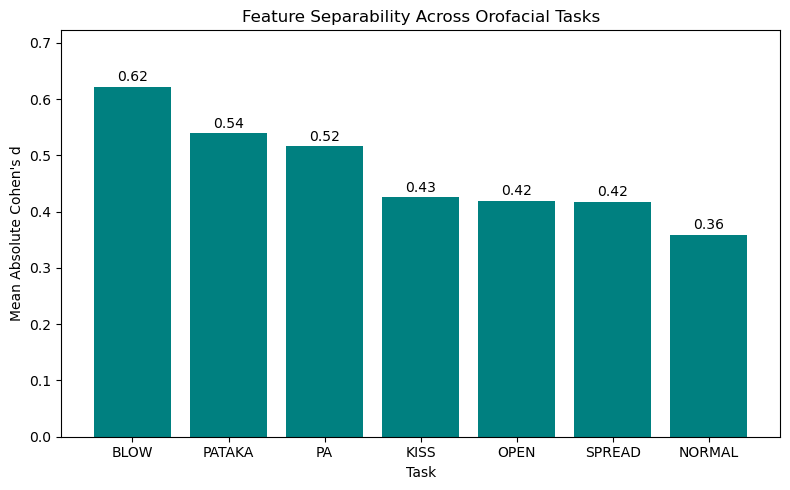

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# LOAD RESULTS
# =========================

df = pd.read_csv("task_separability_AU_statistics.csv")

# Optional nicer names
name_map = {
    "BBP_NORMAL": "NORMAL",
    "DDK_PA": "PA",
    "DDK_PATAKA": "PATAKA",
    "NSM_KISS": "KISS",
    "NSM_OPEN": "OPEN",
    "NSM_SPREAD": "SPREAD",
    "NSM_BLOW": "BLOW"
}

df["Task"] = df["Task"].map(name_map)

# =========================
# SORT
# =========================

df = df.sort_values("Mean_Cohens_d_AU_statistics", ascending=False)

# =========================
# PLOT
# =========================

plt.figure(figsize=(8,5))

bars = plt.bar(
    df["Task"],
    df["Mean_Cohens_d_AU_statistics"],
    color="#008080"
 #   color="#A7AAFF"
 #    color="#058B7C"
    
)

# Add values above bars
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.01,
        f"{h:.2f}",
        ha='center',
        fontsize=10
    )

plt.ylabel("Mean Absolute Cohen's d")
plt.xlabel("Task")
plt.title("Feature Separability Across Orofacial Tasks")

plt.ylim(0, max(df["Mean_Cohens_d_AU_statistics"]) + 0.1)

plt.tight_layout()

plt.savefig("task_separability_plot.png", dpi=300)
plt.show()